Question 1: Does High Revenue Mean high profit?

In [1]:
import pandas as pd

In [3]:
from google.colab import files
uploaded = files.upload()

Saving BI_Retail_Case_Study.xlsx to BI_Retail_Case_Study.xlsx


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(path, sheet_name="SalesRaw")
product = pd.read_excel(path, sheet_name="DimProduct")

In [6]:
import numpy as np

In [7]:
import matplotlib.pyplot as plt

In [8]:
import seaborn as sns

In [9]:
path = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(path, sheet_name="SalesRaw")
product = pd.read_excel(path, sheet_name="DimProduct")

In [10]:
print(sales.head())

  TransactionID TransactionDate  StoreID  EmployeeID  CustomerID  ProductID  \
0      TX100000      2025-06-29        3        2016       10538         10   
1      TX100001      2025-12-31        6        2028       10107         26   
2      TX100002      2025-08-30        2        2036       13854         51   
3      TX100003      2025-06-09        5        2033       11230          3   
4      TX100004      2025-01-10        3        2019       10395         42   

   Quantity  UnitPrice  DiscountPct SalesChannel  PaymentMethod  GrossSales  \
0         2     2660.0         0.10        Store   Mobile Money        5320   
1         6    25204.0         0.05        Store   Mobile Money      151224   
2         1     8468.0         0.05       Online  Bank Transfer        8468   
3         3     1819.0         0.00        Store  Bank Transfer        5457   
4         1     2310.0         0.02        Store           Card        2310   

   DiscountAmount  NetSales  
0           532.0   

In [11]:
print(product.head())

   ProductID     ProductName         Category  StandardUnitPrice  UnitCost
0          1        Rice 5kg  Food & Beverage               6500      4800
1          2  Cooking Oil 1L  Food & Beverage               3200      2400
2          3         Milk 1L  Food & Beverage               1800      1300
3          4       Sugar 1kg  Food & Beverage               1700      1250
4          5   Biscuits Pack  Food & Beverage               1200       800


In [12]:
print(sales.columns)

Index(['TransactionID', 'TransactionDate', 'StoreID', 'EmployeeID',
       'CustomerID', 'ProductID', 'Quantity', 'UnitPrice', 'DiscountPct',
       'SalesChannel', 'PaymentMethod', 'GrossSales', 'DiscountAmount',
       'NetSales'],
      dtype='object')


In [13]:
print(product.columns)

Index(['ProductID', 'ProductName', 'Category', 'StandardUnitPrice',
       'UnitCost'],
      dtype='object')


In [14]:
q1 = sales.merge(
    product[["ProductID", "ProductName", "Category", "UnitCost"]],
    on="ProductID",
    how="left"
)

In [15]:
q1["TotalCost"] = q1["Quantity"] * q1["UnitCost"]

In [16]:
q1["GrossProfit"] = q1["NetSales"] - q1["TotalCost"]

In [17]:
q1_summary = (
    q1.groupby(
        ["ProductID", "ProductName", "Category"]
    )
    .agg(
        Total_Net_Sales=("NetSales", "sum"),
        Total_Quantity_Sold=("Quantity", "sum"),
        Total_Cost=("TotalCost", "sum"),
        Gross_Profit=("GrossProfit", "sum")
    )
    .reset_index()
)

In [18]:
q1_summary["Profit_Margin"] = (
    q1_summary["Gross_Profit"]
    / q1_summary["Total_Net_Sales"]
) * 100

In [19]:
q1_summary.sort_values(
    "Total_Net_Sales",
    ascending=False
).head(10)

,ProductID,ProductName,Category,Total_Net_Sales,Total_Quantity_Sold,Total_Cost,Gross_Profit,Profit_Margin
19,20,Smartphone Midrange,Electronics,3.297730e+08,1067,272085000,57688039.24,17.493255
18,19,Smartphone Entry,Electronics,1.857773e+08,1038,150510000,35267297.96,18.983642
21,22,Blender,Home & Kitchen,4.310346e+07,1066,30381000,12722458.91,29.516097
23,24,Dinner Set,Home & Kitchen,3.804316e+07,1035,25875000,12168156.04,31.985138
29,30,Bedsheet Set,Home & Kitchen,3.683306e+07,1187,24927000,11906056.01,32.324377
44,45,Printer Ink,Office & Stationery,3.497996e+07,1131,25447500,9532462.60,27.251209
58,59,Knapsack Sprayer,Agriculture,3.324617e+07,910,23660000,9586166.92,28.833901
39,40,Perfume,Personal Care,2.967771e+07,1096,20276000,9401705.53,31.679354
20,21,Electric Kettle,Home & Kitchen,2.963228e+07,1092,19656000,9976282.16,33.666938
12,13,Bluetooth Speaker,Electronics,2.858406e+07,1058,19573000,9011056.92,31.524766


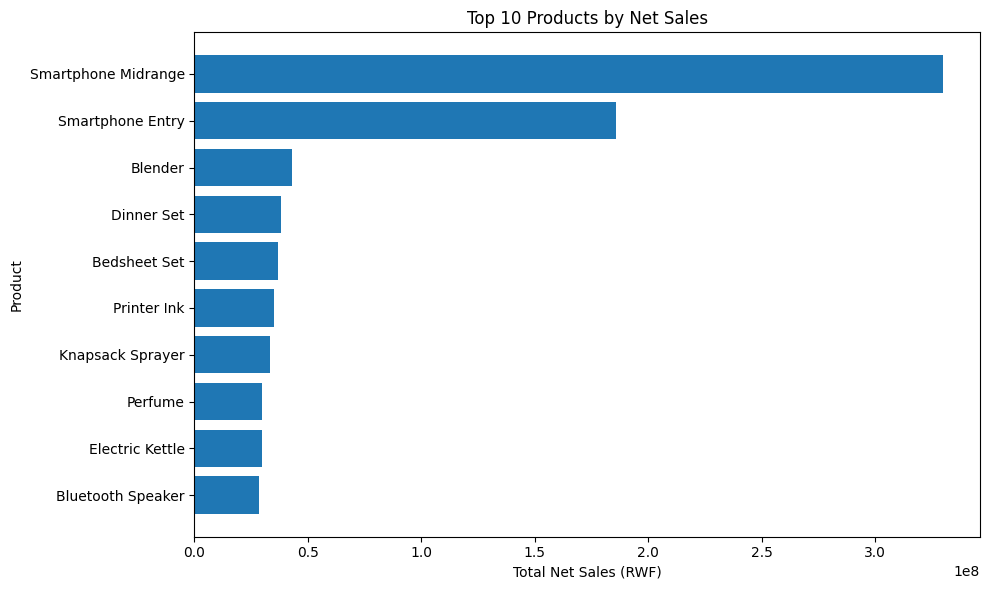

In [20]:
top10 = (
    q1_summary
    .sort_values("Total_Net_Sales", ascending=False)
    .head(10)
    .sort_values("Total_Net_Sales")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["ProductName"],
    top10["Total_Net_Sales"]
)

plt.xlabel("Total Net Sales (RWF)")
plt.ylabel("Product")
plt.title("Top 10 Products by Net Sales")

plt.tight_layout()
plt.show()

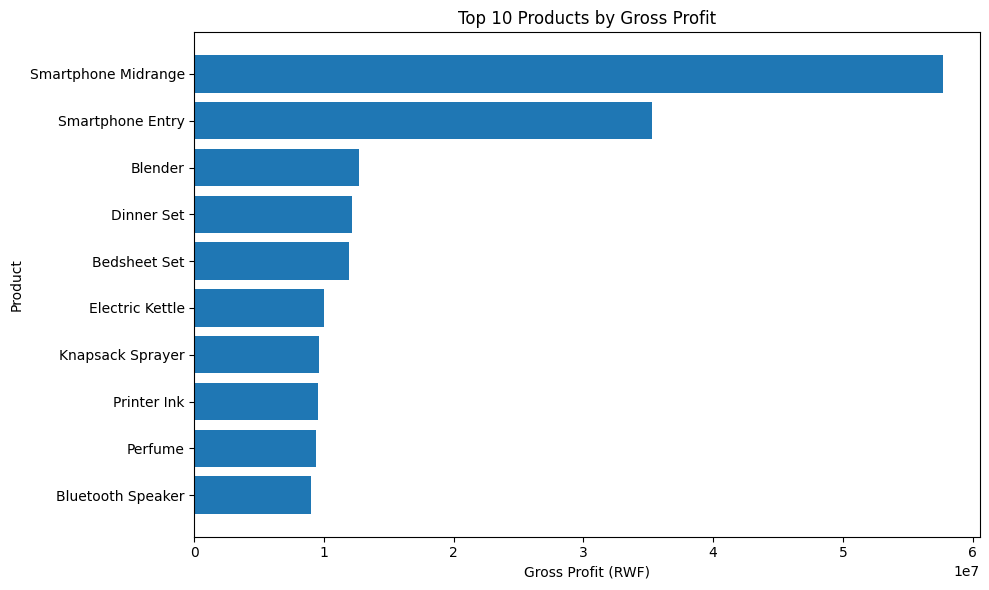

In [21]:
top_profit = (
    q1_summary
    .sort_values("Gross_Profit", ascending=False)
    .head(10)
    .sort_values("Gross_Profit")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_profit["ProductName"],
    top_profit["Gross_Profit"]
)

plt.xlabel("Gross Profit (RWF)")
plt.ylabel("Product")
plt.title("Top 10 Products by Gross Profit")

plt.tight_layout()
plt.show()

In [22]:
q1_summary["SalesRank"] = (
    q1_summary["Total_Net_Sales"]
    .rank(ascending=False, method="min")
    .astype(int)
)

q1_summary["ProfitRank"] = (
    q1_summary["Gross_Profit"]
    .rank(ascending=False, method="min")
    .astype(int)
)

q1_summary["RankGap"] = (
    q1_summary["SalesRank"]
    - q1_summary["ProfitRank"]
)

In [23]:
q1_summary[
    [
        "ProductName",
        "Total_Net_Sales",
        "Gross_Profit",
        "Profit_Margin",
        "SalesRank",
        "ProfitRank",
        "RankGap"
    ]
].sort_values("SalesRank").head(15)

,ProductName,Total_Net_Sales,Gross_Profit,Profit_Margin,SalesRank,ProfitRank,RankGap
19,Smartphone Midrange,3.297730e+08,57688039.24,17.493255,1,1,0
18,Smartphone Entry,1.857773e+08,35267297.96,18.983642,2,2,0
21,Blender,4.310346e+07,12722458.91,29.516097,3,3,0
23,Dinner Set,3.804316e+07,12168156.04,31.985138,4,4,0
29,Bedsheet Set,3.683306e+07,11906056.01,32.324377,5,5,0
44,Printer Ink,3.497996e+07,9532462.60,27.251209,6,8,-2
58,Knapsack Sprayer,3.324617e+07,9586166.92,28.833901,7,7,0
39,Perfume,2.967771e+07,9401705.53,31.679354,8,9,-1
20,Electric Kettle,2.963228e+07,9976282.16,33.666938,9,6,3
12,Bluetooth Speaker,2.858406e+07,9011056.92,31.524766,10,10,0


Question 2: Are Discounts Associated With Sales Perfomance?


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File location
path = "BI_Retail_Case_Study.xlsx"

# Load required sheets
sales = pd.read_excel(path, sheet_name="SalesRaw")
product = pd.read_excel(path, sheet_name="DimProduct")

print("Sales data loaded:", sales.shape)
print("Product data loaded:", product.shape)

print("\nSales columns:")
print(sales.columns.tolist())

print("\nProduct columns:")
print(product.columns.tolist())

Sales data loaded: (25035, 14)
Product data loaded: (60, 5)

Sales columns:
['TransactionID', 'TransactionDate', 'StoreID', 'EmployeeID', 'CustomerID', 'ProductID', 'Quantity', 'UnitPrice', 'DiscountPct', 'SalesChannel', 'PaymentMethod', 'GrossSales', 'DiscountAmount', 'NetSales']

Product columns:
['ProductID', 'ProductName', 'Category', 'StandardUnitPrice', 'UnitCost']


In [29]:
q2 = sales.copy()

# Add UnitCost from DimProduct
q2 = q2.merge(
    product[["ProductID", "UnitCost"]],
    on="ProductID",
    how="left"
)

print("Q2 data created successfully!")
print(q2.head())

Q2 data created successfully!
  TransactionID TransactionDate  StoreID  EmployeeID  CustomerID  ProductID  \
0      TX100000      2025-06-29        3        2016       10538         10   
1      TX100001      2025-12-31        6        2028       10107         26   
2      TX100002      2025-08-30        2        2036       13854         51   
3      TX100003      2025-06-09        5        2033       11230          3   
4      TX100004      2025-01-10        3        2019       10395         42   

   Quantity  UnitPrice  DiscountPct SalesChannel  PaymentMethod  GrossSales  \
0         2     2660.0         0.10        Store   Mobile Money        5320   
1         6    25204.0         0.05        Store   Mobile Money      151224   
2         1     8468.0         0.05       Online  Bank Transfer        8468   
3         3     1819.0         0.00        Store  Bank Transfer        5457   
4         1     2310.0         0.02        Store           Card        2310   

   DiscountAmount  N

In [30]:
q2["TotalCost"] = (
    q2["Quantity"] * q2["UnitCost"]
)

print(q2[[
    "ProductID",
    "Quantity",
    "UnitCost",
    "TotalCost"
]].head())

   ProductID  Quantity  UnitCost  TotalCost
0         10         2      1900       3800
1         26         6     13500      81000
2         51         1      6100       6100
3          3         3      1300       3900
4         42         1      1500       1500


In [31]:
q2["GrossProfit"] = (
    q2["NetSales"] - q2["TotalCost"]
)

print(q2[[
    "NetSales",
    "TotalCost",
    "GrossProfit"
]].head())

   NetSales  TotalCost  GrossProfit
0    4788.0       3800        988.0
1  143662.8      81000      62662.8
2    8044.6       6100       1944.6
3    5457.0       3900       1557.0
4    2263.8       1500        763.8


In [32]:
numeric_cols = [
    "DiscountPct",
    "DiscountAmount",
    "GrossSales",
    "NetSales",
    "Quantity",
    "GrossProfit"
]

for col in numeric_cols:
    q2[col] = pd.to_numeric(
        q2[col],
        errors="coerce"
    )

print("Numeric conversion completed successfully!")

Numeric conversion completed successfully!


In [33]:
q2.head()

,TransactionID,TransactionDate,StoreID,EmployeeID,CustomerID,ProductID,Quantity,UnitPrice,DiscountPct,SalesChannel,PaymentMethod,GrossSales,DiscountAmount,NetSales,UnitCost,TotalCost,GrossProfit
0,TX100000,2025-06-29,3,2016,10538,10,2,2660.0,0.10,Store,Mobile Money,5320,532.0,4788.0,1900,3800,988.0
1,TX100001,2025-12-31,6,2028,10107,26,6,25204.0,0.05,Store,Mobile Money,151224,7561.2,143662.8,13500,81000,62662.8
2,TX100002,2025-08-30,2,2036,13854,51,1,8468.0,0.05,Online,Bank Transfer,8468,423.4,8044.6,6100,6100,1944.6
3,TX100003,2025-06-09,5,2033,11230,3,3,1819.0,0.00,Store,Bank Transfer,5457,0.0,5457.0,1300,3900,1557.0
4,TX100004,2025-01-10,3,2019,10395,42,1,2310.0,0.02,Store,Card,2310,46.2,2263.8,1500,1500,763.8


In [34]:
q2_stats = q2[
    [
        "DiscountPct",
        "DiscountAmount",
        "GrossSales",
        "NetSales",
        "Quantity",
        "GrossProfit"
    ]
].describe()

q2_stats.round(2)

,DiscountPct,DiscountAmount,GrossSales,NetSales,Quantity,GrossProfit
count,24975.00,25035.00,25035.00,25035.00,25035.00,25035.00
mean,0.04,2170.12,51475.81,49305.69,2.59,13161.23
std,0.05,9513.24,152339.45,146195.63,1.90,29936.50
min,0.00,0.00,801.00,649.60,1.00,-45319.20
25%,0.00,0.00,7673.50,7331.74,1.00,2325.38
50%,0.02,342.48,17681.00,17010.00,2.00,5675.88
75%,0.08,1390.50,40485.00,38589.00,3.00,12967.00
max,0.20,295181.10,3230810.00,3099112.80,10.00,752670.00


In [35]:
q2_corr = q2[
    [
        "DiscountPct",
        "DiscountAmount",
        "GrossSales",
        "NetSales",
        "Quantity",
        "GrossProfit"
    ]
].corr()

q2_corr.round(3)

,DiscountPct,DiscountAmount,GrossSales,NetSales,Quantity,GrossProfit
DiscountPct,1.000,0.251,0.001,-0.015,0.001,-0.078
DiscountAmount,0.251,1.000,0.664,0.627,0.167,0.428
GrossSales,0.001,0.664,1.000,0.999,0.247,0.910
NetSales,-0.015,0.627,0.999,1.000,0.246,0.920
Quantity,0.001,0.167,0.247,0.246,1.000,0.317
GrossProfit,-0.078,0.428,0.910,0.920,0.317,1.000


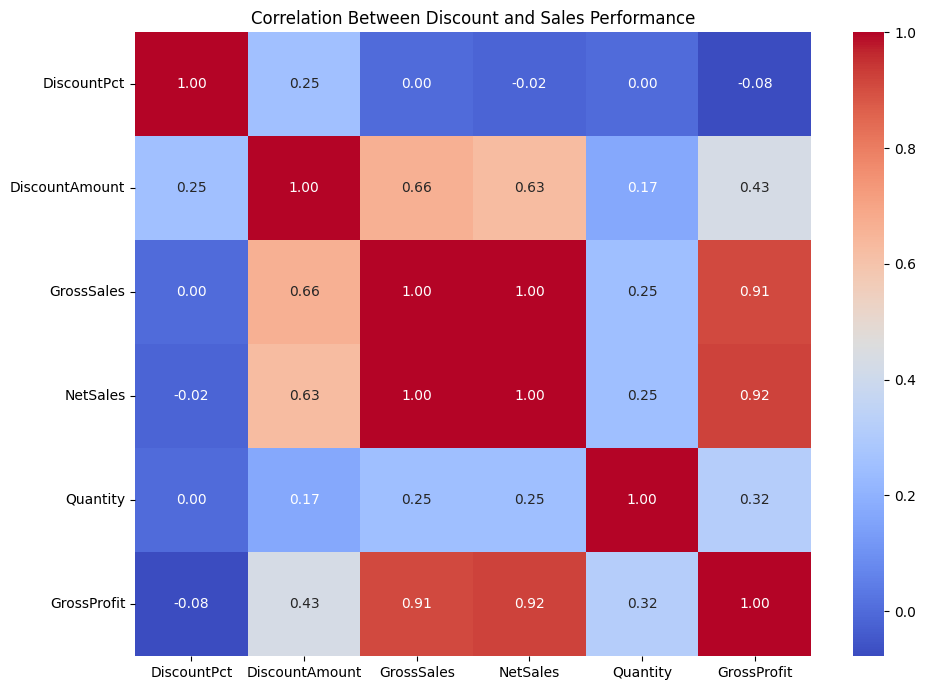

In [36]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    q2_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Between Discount and Sales Performance"
)

plt.tight_layout()
plt.show()

In [37]:
discount_summary = (
    q2.groupby("DiscountPct")
    .agg(
        Transactions=("TransactionID", "nunique"),
        Net_Sales=("NetSales", "sum"),
        Quantity=("Quantity", "sum"),
        Gross_Profit=("GrossProfit", "sum")
    )
    .reset_index()
)

discount_summary

,DiscountPct,Transactions,Net_Sales,Quantity,Gross_Profit
0,0.00,8387,4.355205e+08,21746,1.294653e+08
1,0.02,5035,2.511128e+08,12818,7.018167e+07
2,0.05,4942,2.318449e+08,13025,6.248024e+07
3,0.08,3023,1.592791e+08,7979,3.639225e+07
4,0.10,2035,8.633106e+07,5326,1.982686e+07
5,0.15,1009,4.747578e+07,2648,7.937234e+06
6,0.20,509,1.979552e+07,1212,2.449069e+06


In [38]:
discount_display = discount_summary.copy()

discount_display["DiscountPct"] = (
    discount_display["DiscountPct"] * 100
).round(0)

discount_display["Net_Sales"] = (
    discount_display["Net_Sales"] / 1_000_000
).round(2)

discount_display["Gross_Profit"] = (
    discount_display["Gross_Profit"] / 1_000_000
).round(2)

discount_display

,DiscountPct,Transactions,Net_Sales,Quantity,Gross_Profit
0,0.0,8387,435.52,21746,129.47
1,2.0,5035,251.11,12818,70.18
2,5.0,4942,231.84,13025,62.48
3,8.0,3023,159.28,7979,36.39
4,10.0,2035,86.33,5326,19.83
5,15.0,1009,47.48,2648,7.94
6,20.0,509,19.80,1212,2.45


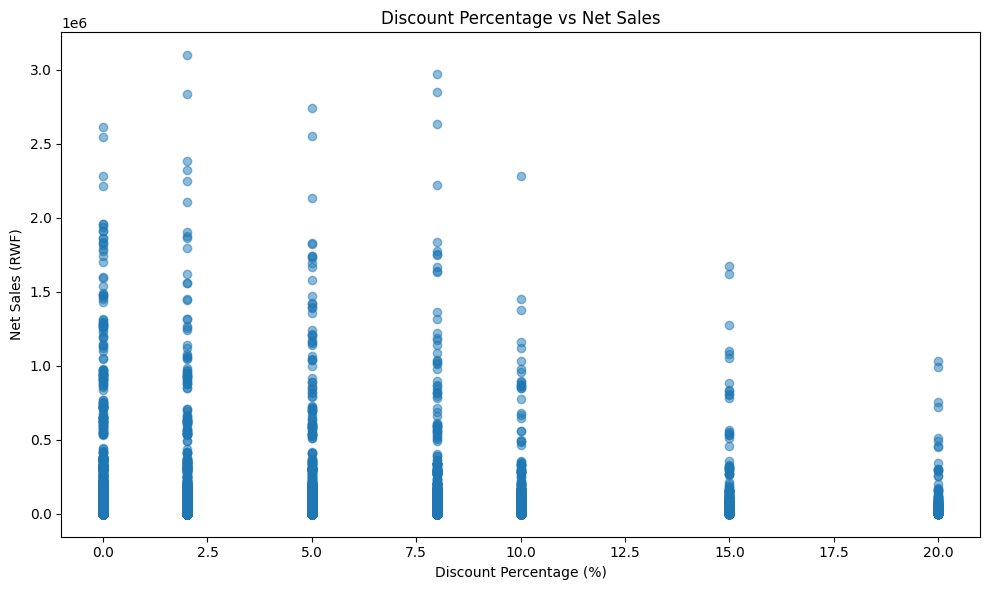

In [39]:
plt.figure(figsize=(10, 6))

plt.scatter(
    q2["DiscountPct"] * 100,
    q2["NetSales"],
    alpha=0.5
)

plt.xlabel("Discount Percentage (%)")
plt.ylabel("Net Sales (RWF)")
plt.title("Discount Percentage vs Net Sales")

plt.tight_layout()
plt.show()

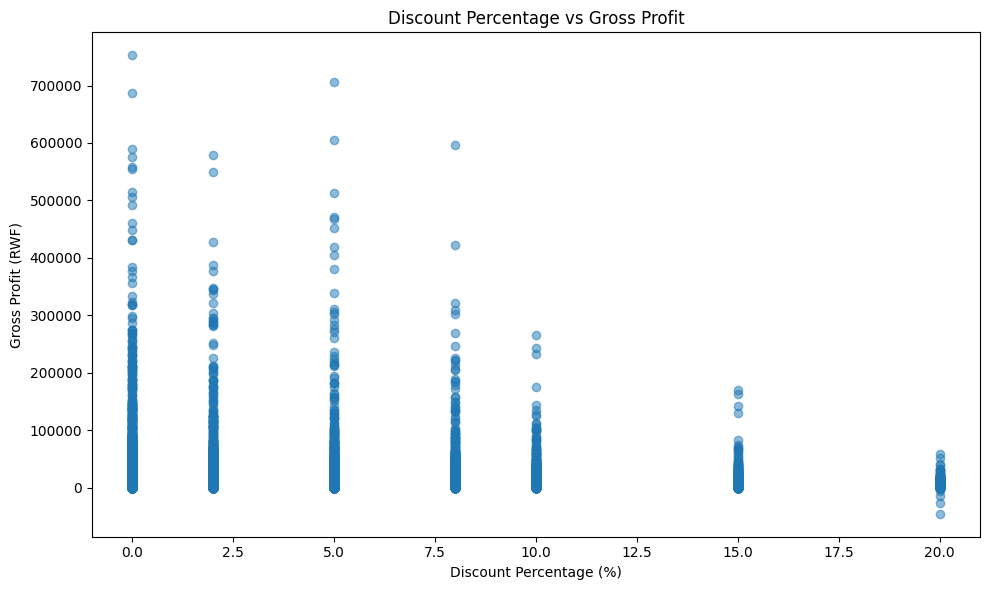

In [40]:
plt.figure(figsize=(10, 6))

plt.scatter(
    q2["DiscountPct"] * 100,
    q2["GrossProfit"],
    alpha=0.5
)

plt.xlabel("Discount Percentage (%)")
plt.ylabel("Gross Profit (RWF)")
plt.title("Discount Percentage vs Gross Profit")

plt.tight_layout()
plt.show()

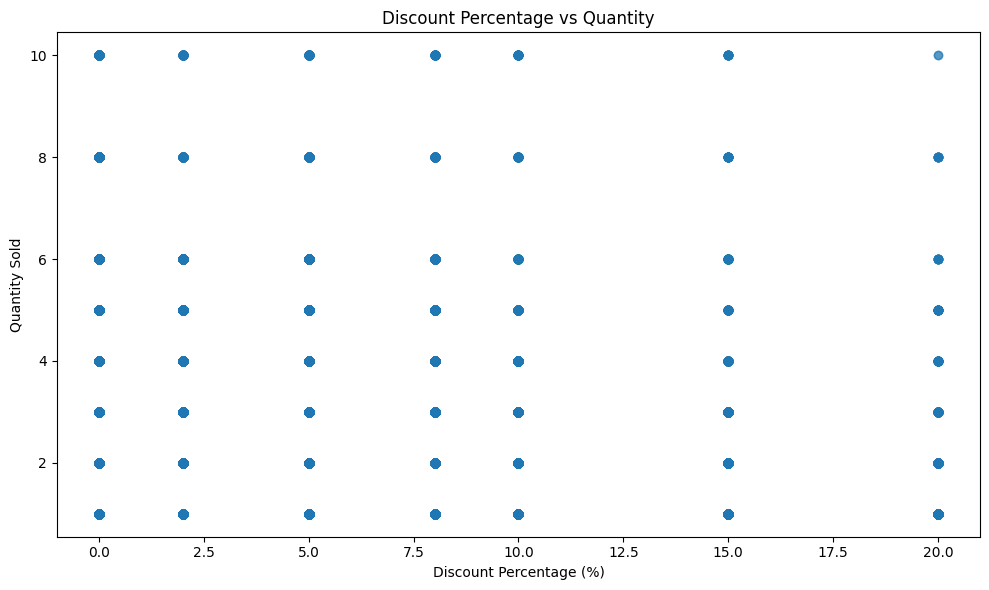

In [41]:
plt.figure(figsize=(10, 6))

plt.scatter(
    q2["DiscountPct"] * 100,
    q2["Quantity"],
    alpha=0.5
)

plt.xlabel("Discount Percentage (%)")
plt.ylabel("Quantity Sold")
plt.title("Discount Percentage vs Quantity")

plt.tight_layout()
plt.show()

In [42]:
print("QUESTION 2 RESULTS")
print("===================")

print(
    "Discount vs Net Sales correlation:",
    round(
        q2_corr.loc["DiscountPct", "NetSales"],
        3
    )
)

print(
    "Discount vs Quantity correlation:",
    round(
        q2_corr.loc["DiscountPct", "Quantity"],
        3
    )
)

print(
    "Discount vs Gross Profit correlation:",
    round(
        q2_corr.loc["DiscountPct", "GrossProfit"],
        3
    )
)

QUESTION 2 RESULTS
Discount vs Net Sales correlation: -0.015
Discount vs Quantity correlation: 0.001
Discount vs Gross Profit correlation: -0.078


In [43]:
q2 = sales.copy()

...

"GrossProfit"

'GrossProfit'

Question 3: Which store is Really Performing Best?

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
path = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(path, sheet_name="SalesRaw")
store = pd.read_excel(path, sheet_name="DimStore")
product = pd.read_excel(path, sheet_name="DimProduct")

In [46]:
print("Sales columns:")
print(sales.columns.tolist())

print("\nStore columns:")
print(store.columns.tolist())

print("\nProduct columns:")
print(product.columns.tolist())

Sales columns:
['TransactionID', 'TransactionDate', 'StoreID', 'EmployeeID', 'CustomerID', 'ProductID', 'Quantity', 'UnitPrice', 'DiscountPct', 'SalesChannel', 'PaymentMethod', 'GrossSales', 'DiscountAmount', 'NetSales']

Store columns:
['StoreID', 'StoreName', 'District', 'Province', 'StoreType']

Product columns:
['ProductID', 'ProductName', 'Category', 'StandardUnitPrice', 'UnitCost']


In [47]:
q3 = sales.merge(
    store[["StoreID", "StoreName", "StoreType", "Province"]],
    on="StoreID",
    how="left"
)

In [48]:
on="StoreID"

In [49]:
q3 = q3.merge(
    product[["ProductID", "UnitCost"]],
    on="ProductID",
    how="left"
)

In [50]:
q3["TotalCost"] = q3["Quantity"] * q3["UnitCost"]

In [51]:
q3["GrossProfit"] = q3["NetSales"] - q3["TotalCost"]

In [52]:
q3_summary = (
    q3.groupby(
        ["StoreID", "StoreName", "StoreType", "Province"]
    )
    .agg(
        Total_Net_Sales=("NetSales", "sum"),
        Number_of_Transactions=("TransactionID", "nunique"),
        Units_Sold=("Quantity", "sum"),
        Gross_Profit=("GrossProfit", "sum")
    )
    .reset_index()
)

In [53]:
q3_summary["Average_Transaction_Value"] = (
    q3_summary["Total_Net_Sales"] /
    q3_summary["Number_of_Transactions"]
)

In [54]:
q3_summary["Profit_Margin_%"] = (
    q3_summary["Gross_Profit"] /
    q3_summary["Total_Net_Sales"]
) * 100

In [55]:
q3_display = q3_summary.copy()

q3_display["Total_Net_Sales"] = (
    q3_display["Total_Net_Sales"] / 1_000_000
).round(2)

q3_display["Gross_Profit"] = (
    q3_display["Gross_Profit"] / 1_000_000
).round(2)

q3_display["Average_Transaction_Value"] = (
    q3_display["Average_Transaction_Value"]
).round(2)

q3_display["Profit_Margin_%"] = (
    q3_display["Profit_Margin_%"]
).round(2)

q3_display

,StoreID,StoreName,StoreType,Province,Total_Net_Sales,Number_of_Transactions,Units_Sold,Gross_Profit,Average_Transaction_Value,Profit_Margin_%
0,1,Kigali City Centre,Urban,Kigali,244.47,4919,12800,66.41,49698.79,27.16
1,2,Kimironko,Urban,Kigali,185.08,3976,10058,49.55,46548.64,26.77
2,3,Kicukiro Mall,Urban,Kigali,159.18,3229,8418,42.83,49298.37,26.91
3,4,Musanze Central,Secondary City,Northern,138.98,2739,7174,37.27,50740.17,26.82
4,5,Rubavu Centre,Secondary City,Western,129.66,2421,6293,32.99,53556.69,25.45
5,6,Huye Market,Secondary City,Southern,120.25,2543,6668,31.81,47286.80,26.45
6,7,Nyagatare Plaza,Secondary City,Eastern,132.52,2622,6856,35.19,50540.47,26.55
7,8,Muhanga Hub,Secondary City,Southern,124.23,2551,6639,33.45,48699.47,26.93


In [56]:
q3_sales_rank = q3_display.sort_values(
    "Total_Net_Sales",
    ascending=False
)

q3_sales_rank

,StoreID,StoreName,StoreType,Province,Total_Net_Sales,Number_of_Transactions,Units_Sold,Gross_Profit,Average_Transaction_Value,Profit_Margin_%
0,1,Kigali City Centre,Urban,Kigali,244.47,4919,12800,66.41,49698.79,27.16
1,2,Kimironko,Urban,Kigali,185.08,3976,10058,49.55,46548.64,26.77
2,3,Kicukiro Mall,Urban,Kigali,159.18,3229,8418,42.83,49298.37,26.91
3,4,Musanze Central,Secondary City,Northern,138.98,2739,7174,37.27,50740.17,26.82
6,7,Nyagatare Plaza,Secondary City,Eastern,132.52,2622,6856,35.19,50540.47,26.55
4,5,Rubavu Centre,Secondary City,Western,129.66,2421,6293,32.99,53556.69,25.45
7,8,Muhanga Hub,Secondary City,Southern,124.23,2551,6639,33.45,48699.47,26.93
5,6,Huye Market,Secondary City,Southern,120.25,2543,6668,31.81,47286.80,26.45


In [57]:
highest_margin = q3_summary.loc[
    q3_summary["Profit_Margin_%"].idxmax()
]

print("Store with highest profit margin:")
print(highest_margin["StoreName"])
print(
    "Profit Margin:",
    round(highest_margin["Profit_Margin_%"], 2),
    "%"
)

Store with highest profit margin:
Kigali City Centre
Profit Margin: 27.16 %


In [58]:
highest_atv = q3_summary.loc[
    q3_summary["Average_Transaction_Value"].idxmax()
]

print("Store with highest average transaction value:")
print(highest_atv["StoreName"])
print(
    "Average Transaction Value:",
    round(highest_atv["Average_Transaction_Value"], 2),
    "RWF"
)

Store with highest average transaction value:
Rubavu Centre
Average Transaction Value: 53556.69 RWF


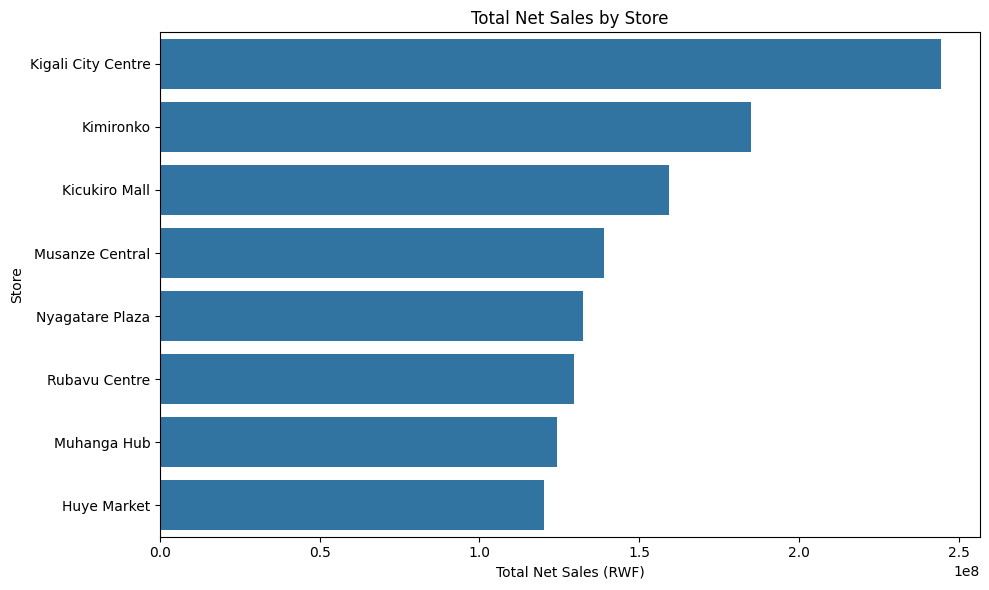

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=q3_summary.sort_values(
        "Total_Net_Sales",
        ascending=False
    ),
    x="Total_Net_Sales",
    y="StoreName"
)

plt.xlabel("Total Net Sales (RWF)")
plt.ylabel("Store")
plt.title("Total Net Sales by Store")
plt.tight_layout()
plt.show()

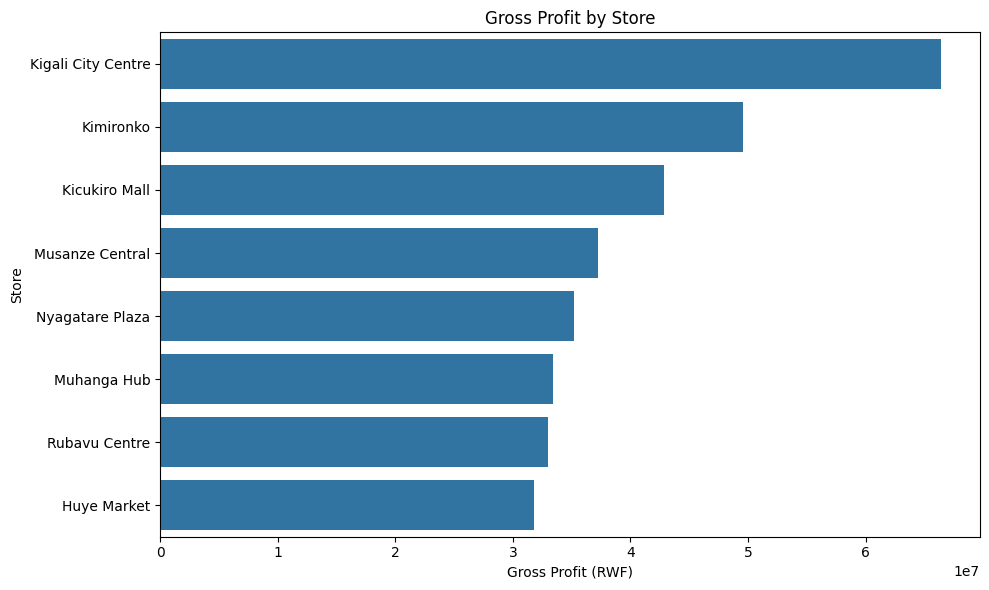

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=q3_summary.sort_values(
        "Gross_Profit",
        ascending=False
    ),
    x="Gross_Profit",
    y="StoreName"
)

plt.xlabel("Gross Profit (RWF)")
plt.ylabel("Store")
plt.title("Gross Profit by Store")
plt.tight_layout()
plt.show()

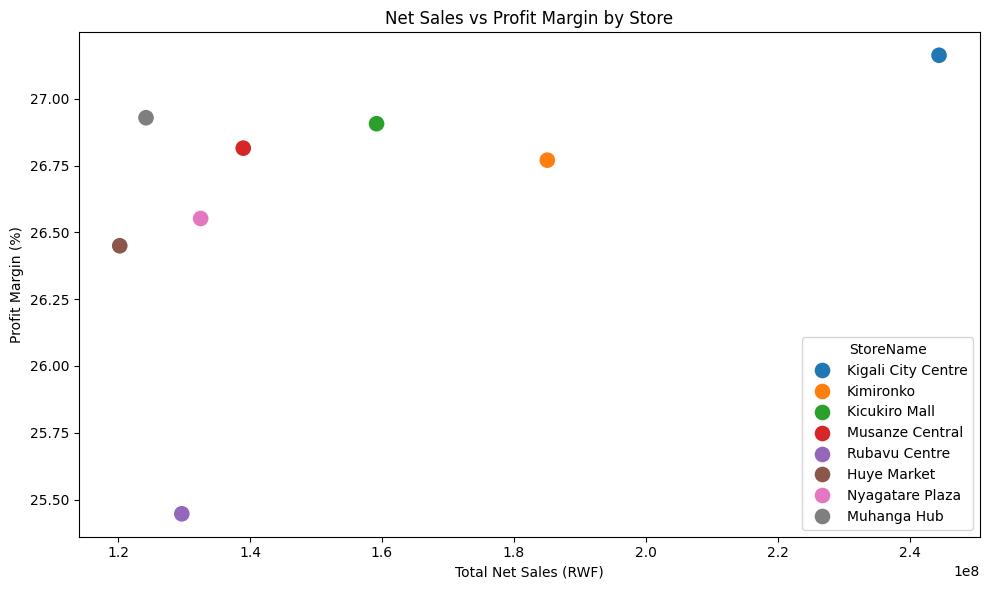

In [61]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=q3_summary,
    x="Total_Net_Sales",
    y="Profit_Margin_%",
    hue="StoreName",
    s=150
)

plt.xlabel("Total Net Sales (RWF)")
plt.ylabel("Profit Margin (%)")
plt.title("Net Sales vs Profit Margin by Store")
plt.tight_layout()
plt.show()

In [62]:
final_q3 = q3_summary[
    [
        "StoreID",
        "StoreName",
        "StoreType",
        "Province",
        "Total_Net_Sales",
        "Number_of_Transactions",
        "Units_Sold",
        "Average_Transaction_Value",
        "Gross_Profit",
        "Profit_Margin_%"
    ]
].sort_values(
    "Total_Net_Sales",
    ascending=False
)

final_q3

,StoreID,StoreName,StoreType,Province,Total_Net_Sales,Number_of_Transactions,Units_Sold,Average_Transaction_Value,Gross_Profit,Profit_Margin_%
0,1,Kigali City Centre,Urban,Kigali,2.444683e+08,4919,12800,49698.786406,66405280.33,27.163142
1,2,Kimironko,Urban,Kigali,1.850774e+08,3976,10058,46548.635817,49545876.01,26.770358
2,3,Kicukiro Mall,Urban,Kigali,1.591844e+08,3229,8418,49298.368356,42831581.42,26.906891
3,4,Musanze Central,Secondary City,Northern,1.389773e+08,2739,7174,50740.173837,37267336.14,26.815405
6,7,Nyagatare Plaza,Secondary City,Eastern,1.325171e+08,2622,6856,50540.467121,35185954.79,26.552010
4,5,Rubavu Centre,Secondary City,Western,1.296607e+08,2421,6293,53556.691132,32994199.23,25.446559
7,8,Muhanga Hub,Secondary City,Southern,1.242324e+08,2551,6639,48699.472846,33454905.23,26.929301
5,6,Huye Market,Secondary City,Southern,1.202503e+08,2543,6668,47286.802957,31806189.92,26.449979


Question 4:Which Customer Type Creates the Most Business Value?

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
path = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(path, sheet_name="SalesRaw")
customer = pd.read_excel(path, sheet_name="DimCustomer")
product = pd.read_excel(path, sheet_name="DimProduct")

In [65]:
print("Sales columns:")
print(sales.columns.tolist())

print("\nCustomer columns:")
print(customer.columns.tolist())

print("\nProduct columns:")
print(product.columns.tolist())

Sales columns:
['TransactionID', 'TransactionDate', 'StoreID', 'EmployeeID', 'CustomerID', 'ProductID', 'Quantity', 'UnitPrice', 'DiscountPct', 'SalesChannel', 'PaymentMethod', 'GrossSales', 'DiscountAmount', 'NetSales']

Customer columns:
['CustomerID', 'CustomerType', 'Gender', 'Age', 'District', 'RegistrationDate']

Product columns:
['ProductID', 'ProductName', 'Category', 'StandardUnitPrice', 'UnitCost']


In [66]:
q4 = sales.merge(
    customer[["CustomerID", "CustomerType"]],
    on="CustomerID",
    how="left"
)

In [69]:
q4 = q4.merge(
    product[["ProductID", "UnitCost"]],
    on="ProductID",
    how="left"
)

In [70]:
q4["TotalCost"] = q4["Quantity"] * q4["UnitCost"]

In [71]:
q4["GrossProfit"] = q4["NetSales"] - q4["TotalCost"]

In [72]:
print(q4["CustomerType"].value_counts())

CustomerType
Individual     18174
SME             5588
Institution     1273
Name: count, dtype: int64


In [73]:
q4_summary = (
    q4.groupby("CustomerType")
    .agg(
        Number_of_Customers=("CustomerID", "nunique"),
        Number_of_Transactions=("TransactionID", "nunique"),
        Total_Net_Sales=("NetSales", "sum"),
        Quantity_Sold=("Quantity", "sum"),
        Gross_Profit=("GrossProfit", "sum")
    )
    .reset_index()
)

In [74]:
q4_summary["Sales_Contribution_%"] = (
    q4_summary["Total_Net_Sales"] /
    q4_summary["Total_Net_Sales"].sum()
) * 100

In [75]:
q4_summary["Average_Transaction_Value"] = (
    q4_summary["Total_Net_Sales"] /
    q4_summary["Number_of_Transactions"]
)

In [76]:
q4_summary["Profit_Margin_%"] = (
    q4_summary["Gross_Profit"] /
    q4_summary["Total_Net_Sales"]
) * 100

In [77]:
q4_display = q4_summary.copy()

q4_display["Total_Net_Sales"] = (
    q4_display["Total_Net_Sales"] / 1_000_000
).round(2)

q4_display["Gross_Profit"] = (
    q4_display["Gross_Profit"] / 1_000_000
).round(2)

q4_display["Sales_Contribution_%"] = (
    q4_display["Sales_Contribution_%"]
).round(2)

q4_display["Average_Transaction_Value"] = (
    q4_display["Average_Transaction_Value"]
).round(2)

q4_display["Profit_Margin_%"] = (
    q4_display["Profit_Margin_%"]
).round(2)

q4_display

,CustomerType,Number_of_Customers,Number_of_Transactions,Total_Net_Sales,Quantity_Sold,Gross_Profit,Sales_Contribution_%,Average_Transaction_Value,Profit_Margin_%
0,Individual,3600,18146,892.64,47176,238.11,72.32,49192.12,26.67
1,Institution,256,1271,72.29,3350,18.46,5.86,56877.08,25.54
2,SME,1119,5583,269.44,14380,72.92,21.83,48260.25,27.07


In [78]:
highest_sales_customer = q4_summary.loc[
    q4_summary["Total_Net_Sales"].idxmax()
]

print("Customer type with highest sales:")
print(highest_sales_customer["CustomerType"])

print(
    "Total Net Sales:",
    round(highest_sales_customer["Total_Net_Sales"] / 1_000_000, 2),
    "million RWF"
)

Customer type with highest sales:
Individual
Total Net Sales: 892.64 million RWF


In [79]:
highest_profit_customer = q4_summary.loc[
    q4_summary["Gross_Profit"].idxmax()
]

print("Customer type with highest gross profit:")
print(highest_profit_customer["CustomerType"])

print(
    "Gross Profit:",
    round(highest_profit_customer["Gross_Profit"] / 1_000_000, 2),
    "million RWF"
)

Customer type with highest gross profit:
Individual
Gross Profit: 238.11 million RWF


In [80]:
highest_margin_customer = q4_summary.loc[
    q4_summary["Profit_Margin_%"].idxmax()
]

print("Customer type with highest profit margin:")
print(highest_margin_customer["CustomerType"])

print(
    "Profit Margin:",
    round(highest_margin_customer["Profit_Margin_%"], 2),
    "%"
)

Customer type with highest profit margin:
SME
Profit Margin: 27.07 %


In [81]:
highest_transaction = q4_summary.loc[
    q4_summary["Average_Transaction_Value"].idxmax()
]

print("Customer type with highest average transaction value:")
print(highest_transaction["CustomerType"])

print(
    "Average Transaction Value:",
    round(highest_transaction["Average_Transaction_Value"], 2),
    "RWF"
)

Customer type with highest average transaction value:
Institution
Average Transaction Value: 56877.08 RWF


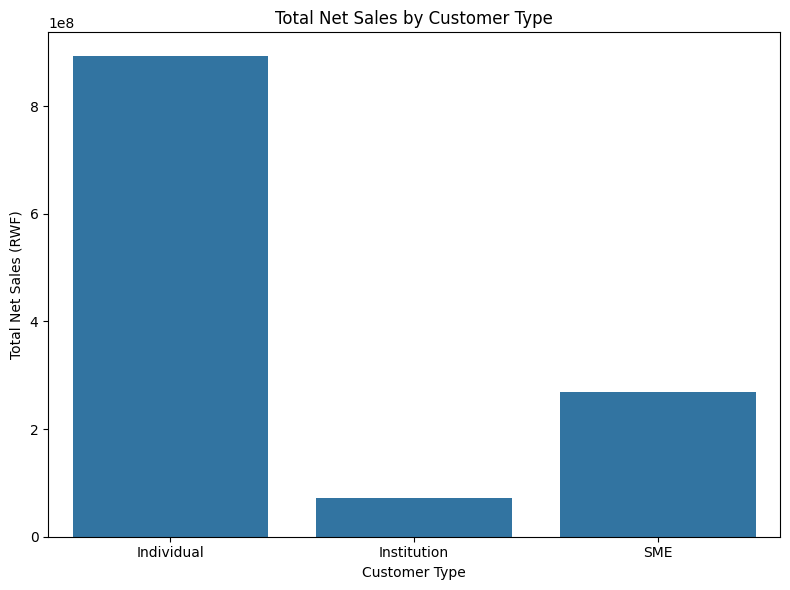

In [82]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=q4_summary,
    x="CustomerType",
    y="Total_Net_Sales"
)

plt.xlabel("Customer Type")
plt.ylabel("Total Net Sales (RWF)")
plt.title("Total Net Sales by Customer Type")
plt.tight_layout()
plt.show()

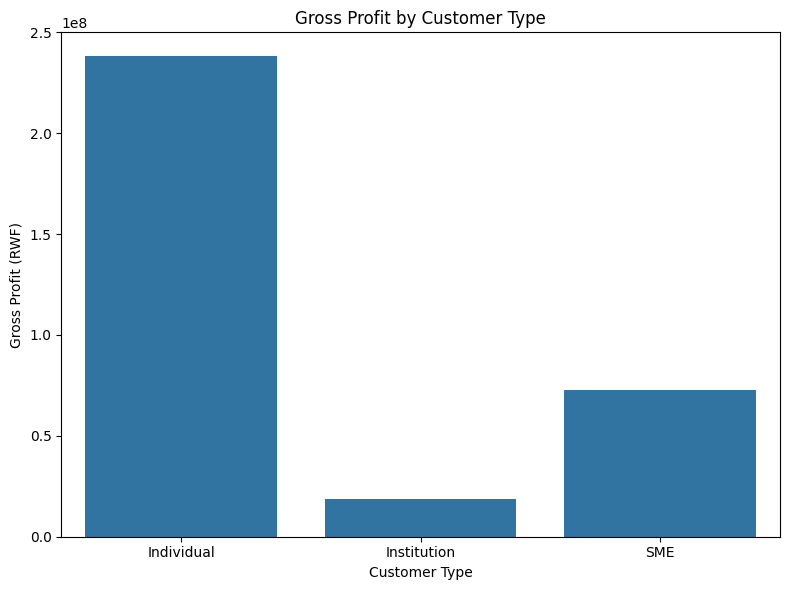

In [83]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=q4_summary,
    x="CustomerType",
    y="Gross_Profit"
)

plt.xlabel("Customer Type")
plt.ylabel("Gross Profit (RWF)")
plt.title("Gross Profit by Customer Type")
plt.tight_layout()
plt.show()

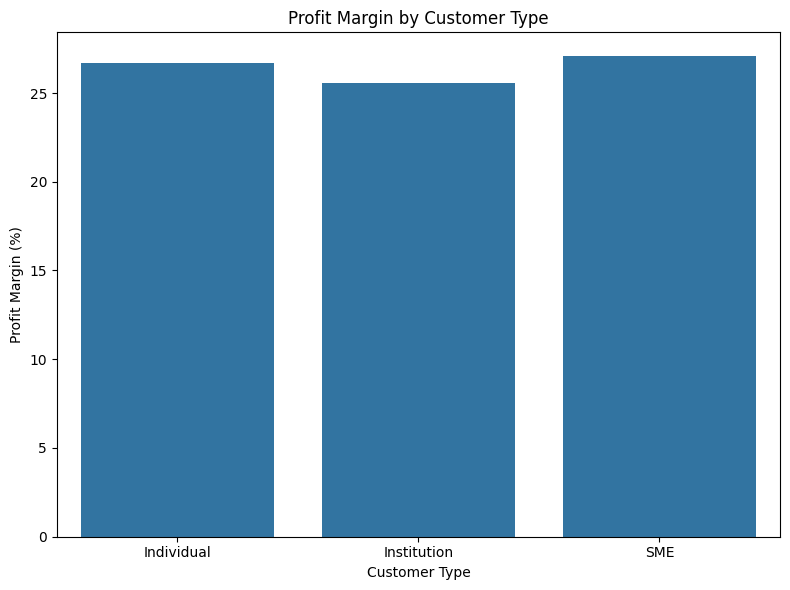

In [84]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=q4_summary,
    x="CustomerType",
    y="Profit_Margin_%"
)

plt.xlabel("Customer Type")
plt.ylabel("Profit Margin (%)")
plt.title("Profit Margin by Customer Type")
plt.tight_layout()
plt.show()

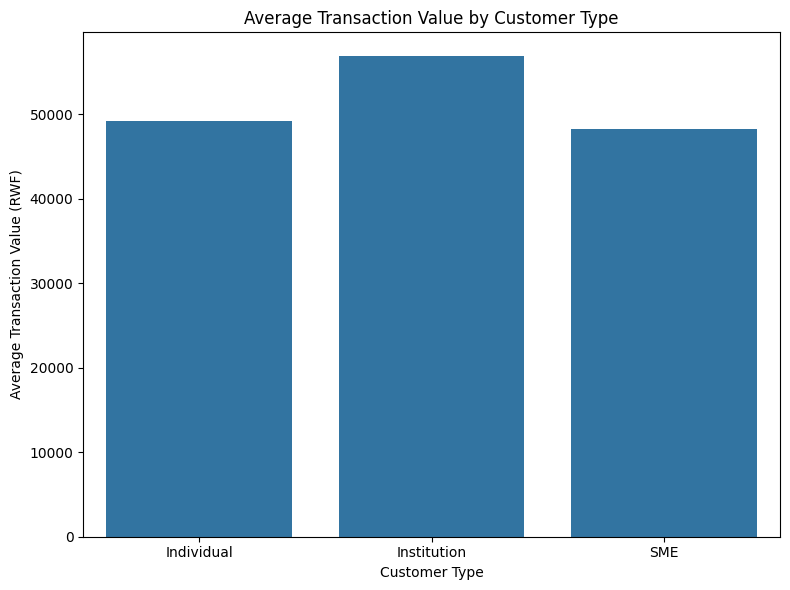

In [85]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=q4_summary,
    x="CustomerType",
    y="Average_Transaction_Value"
)

plt.xlabel("Customer Type")
plt.ylabel("Average Transaction Value (RWF)")
plt.title("Average Transaction Value by Customer Type")
plt.tight_layout()
plt.show()

Question 5: What Is Relationship Between Product price, Quantity and Revenue?

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
path = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(
    path,
    sheet_name="SalesRaw"
)

In [88]:
print(sales[
    [
        "Quantity",
        "UnitPrice",
        "GrossSales",
        "DiscountPct",
        "NetSales"
    ]
].head())

   Quantity  UnitPrice  GrossSales  DiscountPct  NetSales
0         2     2660.0        5320         0.10    4788.0
1         6    25204.0      151224         0.05  143662.8
2         1     8468.0        8468         0.05    8044.6
3         3     1819.0        5457         0.00    5457.0
4         1     2310.0        2310         0.02    2263.8


In [89]:
q5 = sales.copy()

numeric_cols = [
    "Quantity",
    "UnitPrice",
    "GrossSales",
    "DiscountPct",
    "NetSales"
]

for col in numeric_cols:
    q5[col] = pd.to_numeric(
        q5[col],
        errors="coerce"
    )

In [90]:
print(q5[numeric_cols].isnull().sum())

Quantity        0
UnitPrice      50
GrossSales      0
DiscountPct    60
NetSales        0
dtype: int64


In [91]:
q5_stats = q5[
    [
        "Quantity",
        "UnitPrice",
        "GrossSales",
        "DiscountPct",
        "NetSales"
    ]
].describe()

q5_stats.round(2)

,Quantity,UnitPrice,GrossSales,DiscountPct,NetSales
count,25035.00,24985.00,25035.00,24975.00,25035.00
mean,2.59,19806.22,51475.81,0.04,49305.69
std,1.90,45961.76,152339.45,0.05,146195.63
min,1.00,791.00,801.00,0.00,649.60
25%,1.00,4204.00,7673.50,0.00,7331.74
50%,2.00,8330.00,17681.00,0.02,17010.00
75%,3.00,18089.00,40485.00,0.08,38589.00
max,10.00,387691.00,3230810.00,0.20,3099112.80


In [92]:
q5_corr = q5[
    [
        "Quantity",
        "UnitPrice",
        "GrossSales",
        "DiscountPct",
        "NetSales"
    ]
].corr()

q5_corr.round(3)

,Quantity,UnitPrice,GrossSales,DiscountPct,NetSales
Quantity,1.000,0.000,0.247,0.001,0.246
UnitPrice,0.000,1.000,0.790,0.003,0.788
GrossSales,0.247,0.790,1.000,0.001,0.999
DiscountPct,0.001,0.003,0.001,1.000,-0.015
NetSales,0.246,0.788,0.999,-0.015,1.000


In [93]:
print(
    "Correlation between Unit Price and Net Sales:",
    round(q5_corr.loc["UnitPrice", "NetSales"], 3)
)

print(
    "Correlation between Quantity and Net Sales:",
    round(q5_corr.loc["Quantity", "NetSales"], 3)
)

print(
    "Correlation between Discount and Net Sales:",
    round(q5_corr.loc["DiscountPct", "NetSales"], 3)
)

Correlation between Unit Price and Net Sales: 0.788
Correlation between Quantity and Net Sales: 0.246
Correlation between Discount and Net Sales: -0.015


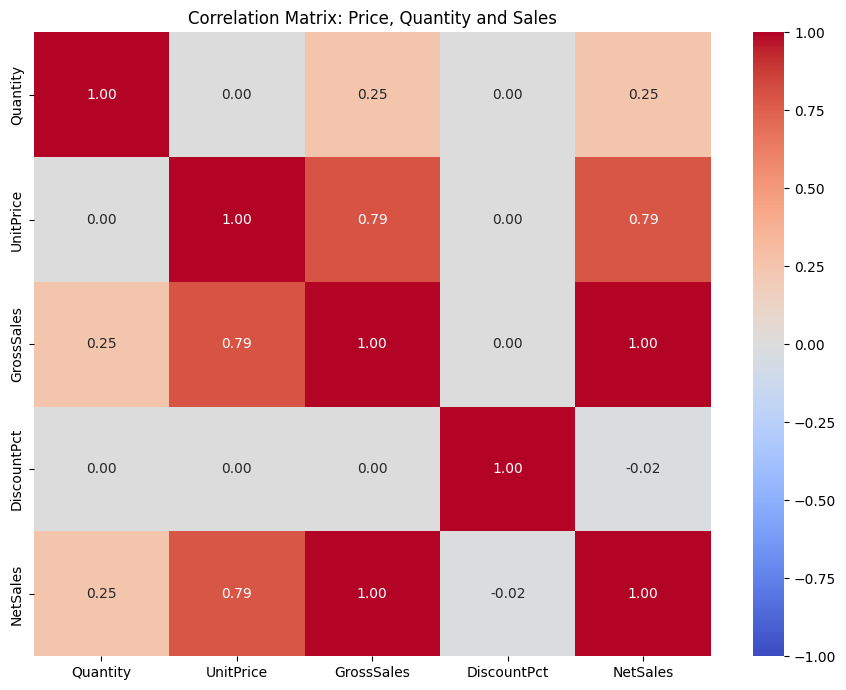

In [94]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    q5_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix: Price, Quantity and Sales")
plt.tight_layout()
plt.show()

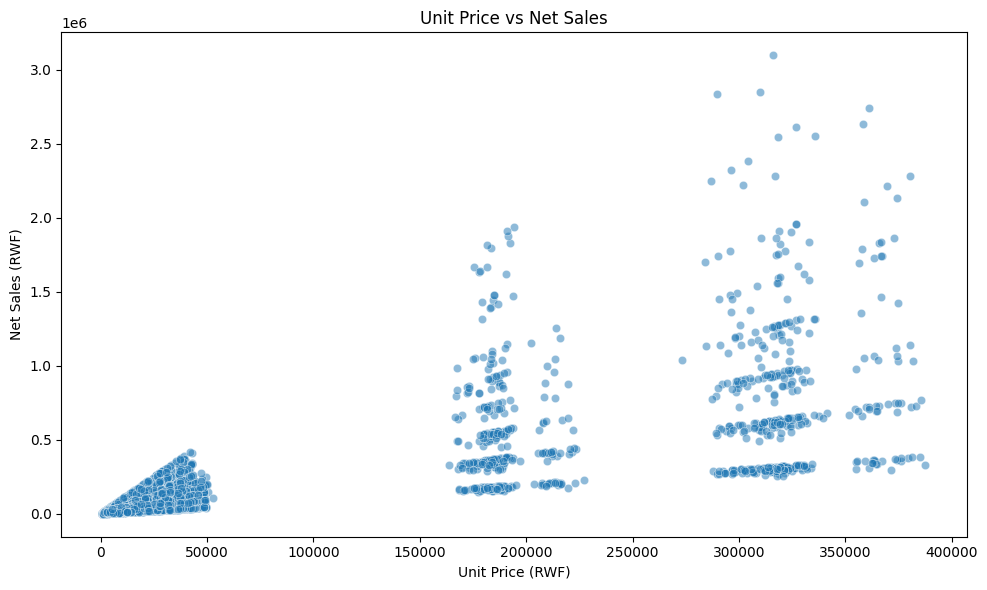

In [95]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=q5,
    x="UnitPrice",
    y="NetSales",
    alpha=0.5
)

plt.xlabel("Unit Price (RWF)")
plt.ylabel("Net Sales (RWF)")
plt.title("Unit Price vs Net Sales")

plt.tight_layout()
plt.show()

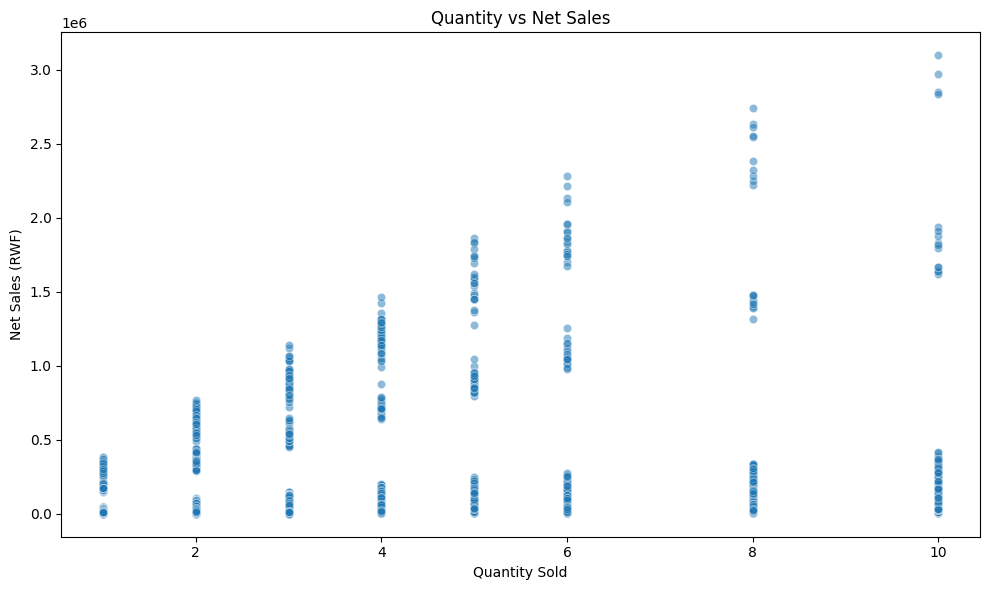

In [96]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=q5,
    x="Quantity",
    y="NetSales",
    alpha=0.5
)

plt.xlabel("Quantity Sold")
plt.ylabel("Net Sales (RWF)")
plt.title("Quantity vs Net Sales")

plt.tight_layout()
plt.show()

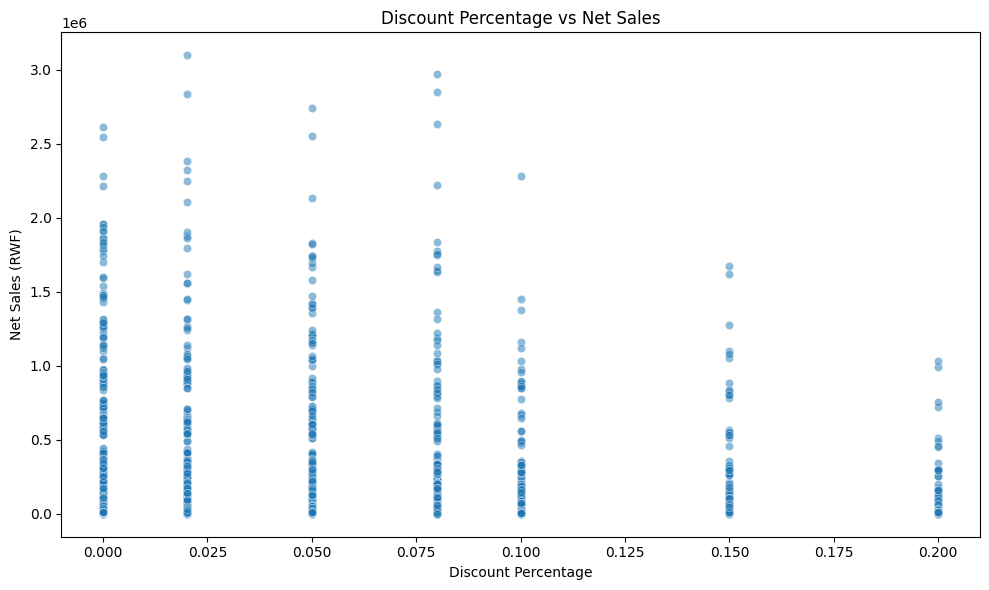

In [97]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=q5,
    x="DiscountPct",
    y="NetSales",
    alpha=0.5
)

plt.xlabel("Discount Percentage")
plt.ylabel("Net Sales (RWF)")
plt.title("Discount Percentage vs Net Sales")

plt.tight_layout()
plt.show()

In [98]:
net_sales_relationships = q5_corr["NetSales"].sort_values(
    ascending=False
)

net_sales_relationships

,NetSales
NetSales,1.000000
GrossSales,0.998816
UnitPrice,0.788208
Quantity,0.246437
DiscountPct,-0.015371


In [99]:
print("QUESTION 5 RESULTS")
print("===================")

print(
    "Quantity vs Net Sales:",
    round(q5_corr.loc["Quantity", "NetSales"], 3)
)

print(
    "Unit Price vs Net Sales:",
    round(q5_corr.loc["UnitPrice", "NetSales"], 3)
)

print(
    "Gross Sales vs Net Sales:",
    round(q5_corr.loc["GrossSales", "NetSales"], 3)
)

print(
    "Discount vs Net Sales:",
    round(q5_corr.loc["DiscountPct", "NetSales"], 3)
)

QUESTION 5 RESULTS
Quantity vs Net Sales: 0.246
Unit Price vs Net Sales: 0.788
Gross Sales vs Net Sales: 0.999
Discount vs Net Sales: -0.015


Question 6:Does the Company Have a Monthly Sales Pattern?

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
path = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(
    path,
    sheet_name="SalesRaw"
)

In [102]:
print(sales["TransactionDate"].head())
print(sales["TransactionDate"].dtype)


0   2025-06-29
1   2025-12-31
2   2025-08-30
3   2025-06-09
4   2025-01-10
Name: TransactionDate, dtype: datetime64[ns]
datetime64[ns]


In [103]:
sales["TransactionDate"] = pd.to_datetime(
    sales["TransactionDate"],
    errors="coerce"
)

In [104]:
print(sales["TransactionDate"].min())
print(sales["TransactionDate"].max())

2025-01-01 00:00:00
2025-12-31 00:00:00


In [105]:
q6 = sales.copy()

q6["Year"] = q6["TransactionDate"].dt.year
q6["Month"] = q6["TransactionDate"].dt.month_name()
q6["MonthNumber"] = q6["TransactionDate"].dt.month

In [106]:
q6["Quarter"] = q6["TransactionDate"].dt.quarter

In [107]:
q6["YearMonth"] = q6["TransactionDate"].dt.to_period("M")

In [108]:
monthly_sales = (
    q6.groupby(
        ["Year", "MonthNumber", "Month", "YearMonth"]
    )
    .agg(
        Net_Sales=("NetSales", "sum"),
        Transactions=("TransactionID", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

In [109]:
monthly_sales["Average_Transaction_Value"] = (
    monthly_sales["Net_Sales"] /
    monthly_sales["Transactions"]
)

In [110]:
monthly_sales = monthly_sales.sort_values(
    ["Year", "MonthNumber"]
).reset_index(drop=True)

In [111]:
monthly_sales["MoM_%"] = (
    monthly_sales["Net_Sales"].pct_change() * 100
)

In [112]:
monthly_display = monthly_sales.copy()

monthly_display["Net_Sales"] = (
    monthly_display["Net_Sales"] / 1_000_000
).round(2)

monthly_display["Average_Transaction_Value"] = (
    monthly_display["Average_Transaction_Value"]
).round(2)

monthly_display["MoM_%"] = (
    monthly_display["MoM_%"]
).round(2)

monthly_display[
    [
        "Month",
        "Net_Sales",
        "Transactions",
        "Quantity",
        "Average_Transaction_Value",
        "MoM_%"
    ]
]

,Month,Net_Sales,Transactions,Quantity,Average_Transaction_Value,MoM_%
0,January,103.73,2235,5878,46409.55,NaN
1,February,93.27,1896,4861,49194.27,-10.08
2,March,103.13,2138,5583,48237.41,10.57
3,April,105.78,2097,5281,50444.63,2.57
4,May,92.70,2052,5336,45174.68,-12.37
5,June,107.70,1997,5262,53932.12,16.19
6,July,102.16,2086,5379,48971.91,-5.15
7,August,101.76,2214,5880,45962.90,-0.39
8,September,106.79,2114,5504,50514.88,4.94
9,October,97.80,2089,5415,46817.12,-8.42


In [113]:
highest_month = monthly_sales.loc[
    monthly_sales["Net_Sales"].idxmax()
]

print("Highest sales month:")
print(highest_month["Month"])
print(
    "Net Sales:",
    round(highest_month["Net_Sales"] / 1_000_000, 2),
    "million RWF"
)

Highest sales month:
November
Net Sales: 111.04 million RWF


In [114]:
lowest_month = monthly_sales.loc[
    monthly_sales["Net_Sales"].idxmin()
]

print("Lowest sales month:")
print(lowest_month["Month"])
print(
    "Net Sales:",
    round(lowest_month["Net_Sales"] / 1_000_000, 2),
    "million RWF"
)

Lowest sales month:
May
Net Sales: 92.7 million RWF


In [115]:
largest_increase = monthly_sales.loc[
    monthly_sales["MoM_%"].idxmax()
]

print("Largest positive MoM change:")
print(largest_increase["Month"])
print(
    "Change:",
    round(largest_increase["MoM_%"], 2),
    "%"
)

Largest positive MoM change:
June
Change: 16.19 %


In [116]:
largest_decrease = monthly_sales.loc[
    monthly_sales["MoM_%"].idxmin()
]

print("Largest negative MoM change:")
print(largest_decrease["Month"])
print(
    "Change:",
    round(largest_decrease["MoM_%"], 2),
    "%"
)

Largest negative MoM change:
May
Change: -12.37 %


In [117]:
quarterly_sales = (
    q6.groupby("Quarter")
    .agg(
        Net_Sales=("NetSales", "sum"),
        Transactions=("TransactionID", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

In [118]:
quarterly_display = quarterly_sales.copy()

quarterly_display["Net_Sales"] = (
    quarterly_display["Net_Sales"] / 1_000_000
).round(2)

quarterly_display

,Quarter,Net_Sales,Transactions,Quantity
0,1,300.13,6269,16322
1,2,306.18,6146,15879
2,3,310.71,6414,16763
3,4,317.35,6171,15942


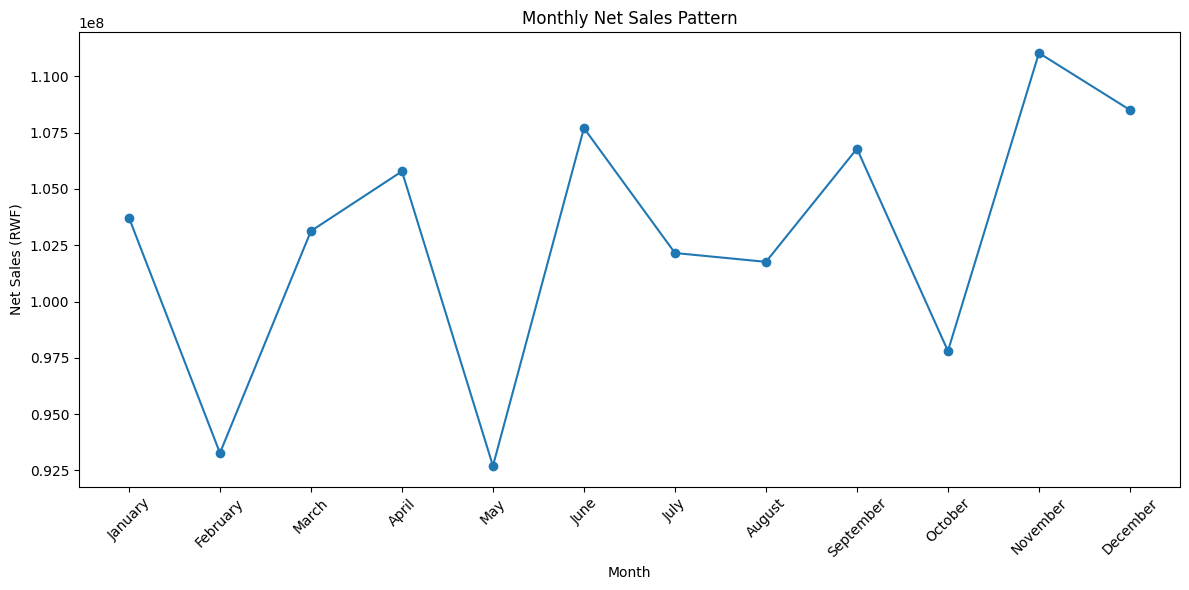

In [119]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Net_Sales"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Net Sales (RWF)")
plt.title("Monthly Net Sales Pattern")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

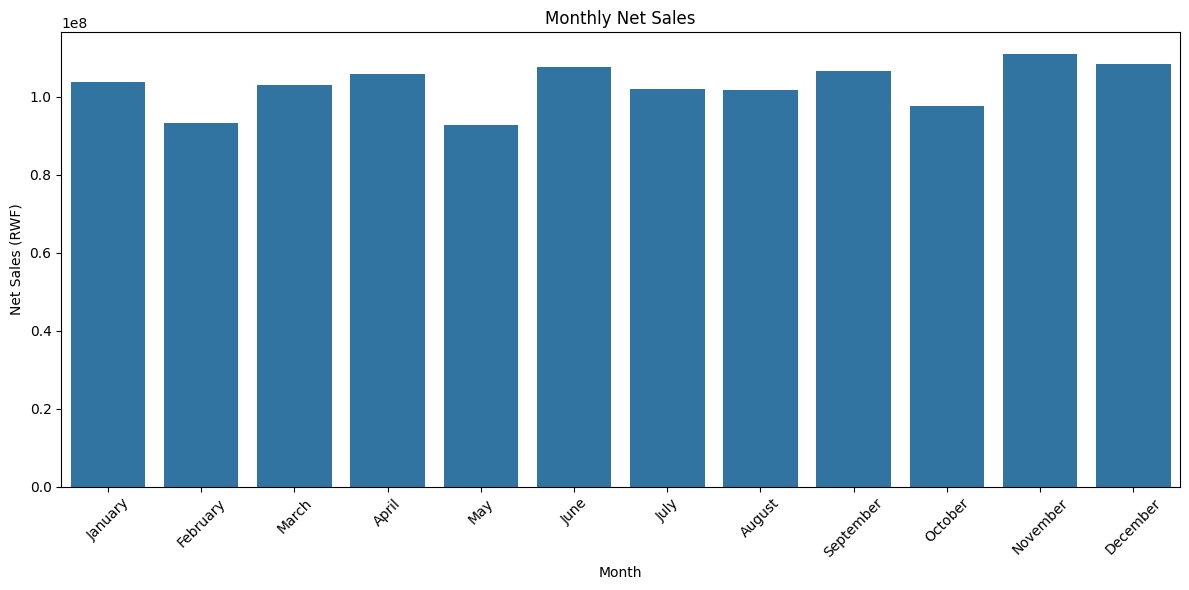

In [120]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_sales,
    x="Month",
    y="Net_Sales"
)

plt.xlabel("Month")
plt.ylabel("Net Sales (RWF)")
plt.title("Monthly Net Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

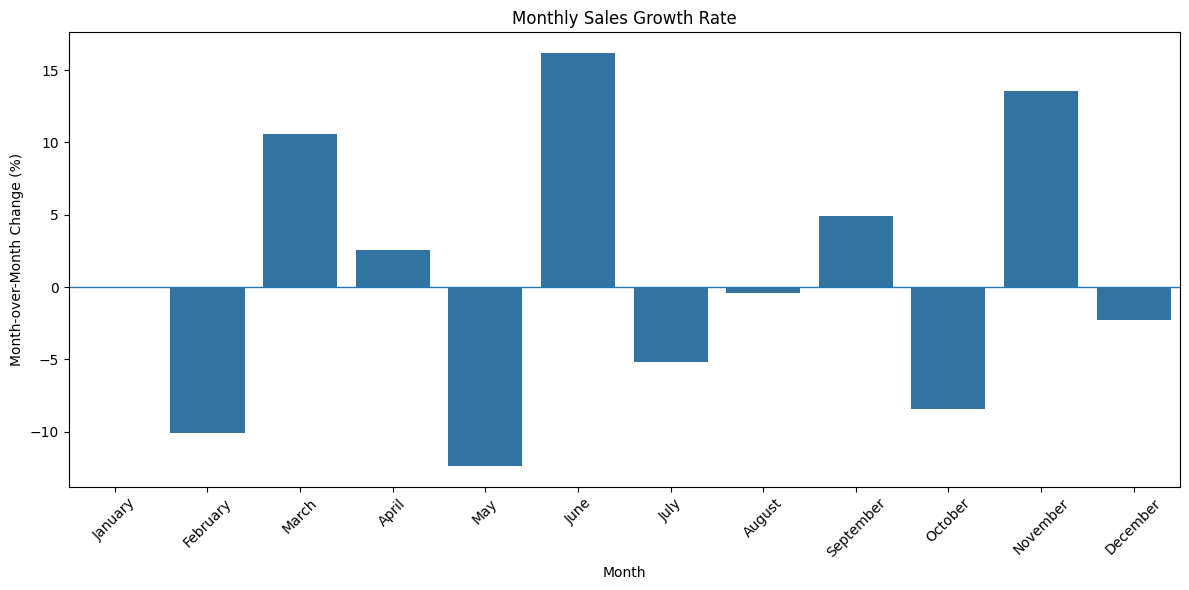

In [121]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=monthly_sales,
    x="Month",
    y="MoM_%"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Month")
plt.ylabel("Month-over-Month Change (%)")
plt.title("Monthly Sales Growth Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

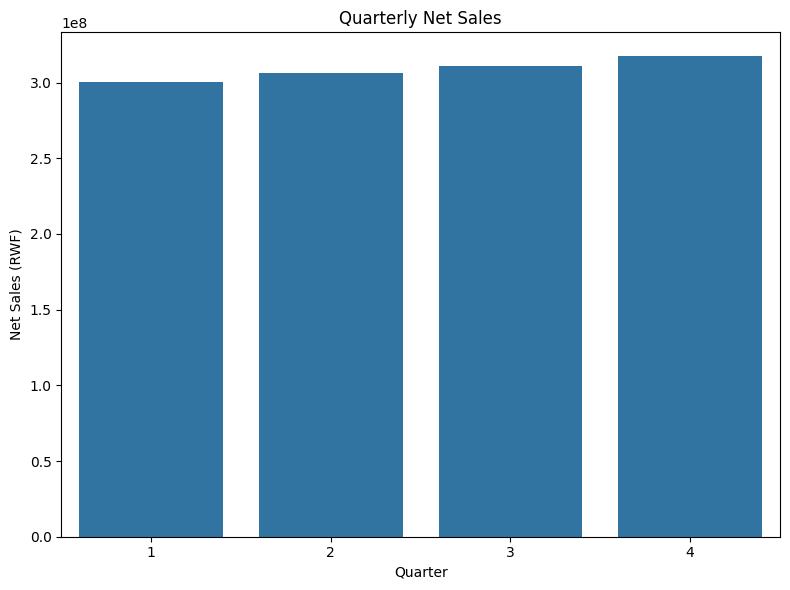

In [122]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=quarterly_sales,
    x="Quarter",
    y="Net_Sales"
)

plt.xlabel("Quarter")
plt.ylabel("Net Sales (RWF)")
plt.title("Quarterly Net Sales")

plt.tight_layout()
plt.show()

In [123]:
print("QUESTION 6 RESULTS")
print("===================")

print(
    "Highest sales month:",
    highest_month["Month"],
    "-",
    round(highest_month["Net_Sales"] / 1_000_000, 2),
    "million RWF"
)

print(
    "Lowest sales month:",
    lowest_month["Month"],
    "-",
    round(lowest_month["Net_Sales"] / 1_000_000, 2),
    "million RWF"
)

print(
    "Largest positive MoM change:",
    largest_increase["Month"],
    "-",
    round(largest_increase["MoM_%"], 2),
    "%"
)

print(
    "Largest negative MoM change:",
    largest_decrease["Month"],
    "-",
    round(largest_decrease["MoM_%"], 2),
    "%"
)

highest_quarter = quarterly_sales.loc[
    quarterly_sales["Net_Sales"].idxmax()
]

print(
    "Highest quarter: Q",
    int(highest_quarter["Quarter"]),
    "-",
    round(highest_quarter["Net_Sales"] / 1_000_000, 2),
    "million RWF"
)

QUESTION 6 RESULTS
Highest sales month: November - 111.04 million RWF
Lowest sales month: May - 92.7 million RWF
Largest positive MoM change: June - 16.19 %
Largest negative MoM change: May - -12.37 %
Highest quarter: Q 4 - 317.35 million RWF


Question 7: Do a Small Number of Products Generate Most Revenue?

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(
    path,
    sheet_name="SalesRaw"
)

product = pd.read_excel(
    path,
    sheet_name="DimProduct"
)

In [125]:
print("Sales columns:")
print(sales.columns.tolist())

print("\nProduct columns:")
print(product.columns.tolist())

Sales columns:
['TransactionID', 'TransactionDate', 'StoreID', 'EmployeeID', 'CustomerID', 'ProductID', 'Quantity', 'UnitPrice', 'DiscountPct', 'SalesChannel', 'PaymentMethod', 'GrossSales', 'DiscountAmount', 'NetSales']

Product columns:
['ProductID', 'ProductName', 'Category', 'StandardUnitPrice', 'UnitCost']


In [126]:
q7 = sales.merge(
    product[["ProductID", "ProductName", "Category"]],
    on="ProductID",
    how="left"
)

In [127]:
q7_summary = (
    q7.groupby(
        ["ProductID", "ProductName", "Category"]
    )
    .agg(
        Total_Net_Sales=("NetSales", "sum")
    )
    .reset_index()
)

In [128]:
q7_summary = q7_summary.sort_values(
    "Total_Net_Sales",
    ascending=False
).reset_index(drop=True)

In [129]:
total_sales = q7_summary["Total_Net_Sales"].sum()

print(
    "Total Net Sales:",
    round(total_sales / 1_000_000, 2),
    "million RWF"
)

Total Net Sales: 1234.37 million RWF


In [130]:
q7_summary["Sales_Contribution_%"] = (
    q7_summary["Total_Net_Sales"] /
    total_sales
) * 100

In [131]:
q7_summary["Cumulative_%"] = (
    q7_summary["Sales_Contribution_%"].cumsum()
)

In [132]:
q7_summary["Rank"] = (
    q7_summary.index + 1
)

In [133]:
q7_top10 = q7_summary[
    [
        "Rank",
        "ProductName",
        "Category",
        "Total_Net_Sales",
        "Sales_Contribution_%",
        "Cumulative_%"
    ]
].head(10).copy()

q7_top10["Total_Net_Sales"] = (
    q7_top10["Total_Net_Sales"] / 1_000_000
).round(2)

q7_top10["Sales_Contribution_%"] = (
    q7_top10["Sales_Contribution_%"]
).round(2)

q7_top10["Cumulative_%"] = (
    q7_top10["Cumulative_%"]
).round(2)

q7_top10

,Rank,ProductName,Category,Total_Net_Sales,Sales_Contribution_%,Cumulative_%
0,1,Smartphone Midrange,Electronics,329.77,26.72,26.72
1,2,Smartphone Entry,Electronics,185.78,15.05,41.77
2,3,Blender,Home & Kitchen,43.10,3.49,45.26
3,4,Dinner Set,Home & Kitchen,38.04,3.08,48.34
4,5,Bedsheet Set,Home & Kitchen,36.83,2.98,51.32
5,6,Printer Ink,Office & Stationery,34.98,2.83,54.16
6,7,Knapsack Sprayer,Agriculture,33.25,2.69,56.85
7,8,Perfume,Personal Care,29.68,2.40,59.26
8,9,Electric Kettle,Home & Kitchen,29.63,2.40,61.66
9,10,Bluetooth Speaker,Electronics,28.58,2.32,63.97


In [134]:
products_50 = (
    q7_summary["Cumulative_%"] >= 50
).idxmax() + 1

print(
    "Number of products needed to reach 50% of sales:",
    products_50
)

Number of products needed to reach 50% of sales: 5


In [135]:
products_70 = (
    q7_summary["Cumulative_%"] >= 70
).idxmax() + 1

print(
    "Number of products needed to reach 70% of sales:",
    products_70
)

Number of products needed to reach 70% of sales: 14


In [136]:
products_80 = (
    q7_summary["Cumulative_%"] >= 80
).idxmax() + 1

print(
    "Number of products needed to reach 80% of sales:",
    products_80
)

Number of products needed to reach 80% of sales: 21


In [137]:
print("QUESTION 7 RESULTS")
print("===================")

print(
    "Products needed for 50% of sales:",
    products_50
)

print(
    "Products needed for 70% of sales:",
    products_70
)

print(
    "Products needed for 80% of sales:",
    products_80
)

QUESTION 7 RESULTS
Products needed for 50% of sales: 5
Products needed for 70% of sales: 14
Products needed for 80% of sales: 21


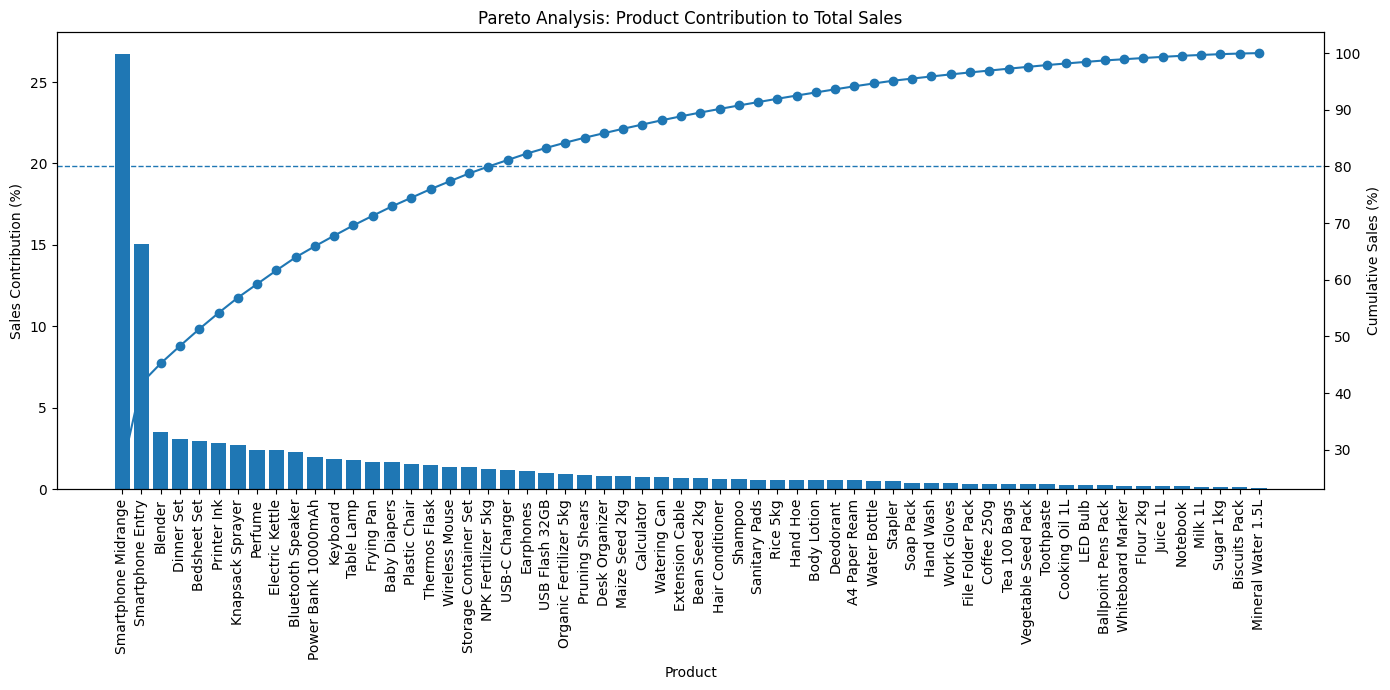

In [138]:
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.bar(
    q7_summary["ProductName"],
    q7_summary["Sales_Contribution_%"]
)

ax1.set_xlabel("Product")
ax1.set_ylabel("Sales Contribution (%)")

ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    q7_summary["ProductName"],
    q7_summary["Cumulative_%"],
    marker="o"
)

ax2.set_ylabel("Cumulative Sales (%)")

ax2.axhline(
    80,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Pareto Analysis: Product Contribution to Total Sales"
)

plt.tight_layout()
plt.show()

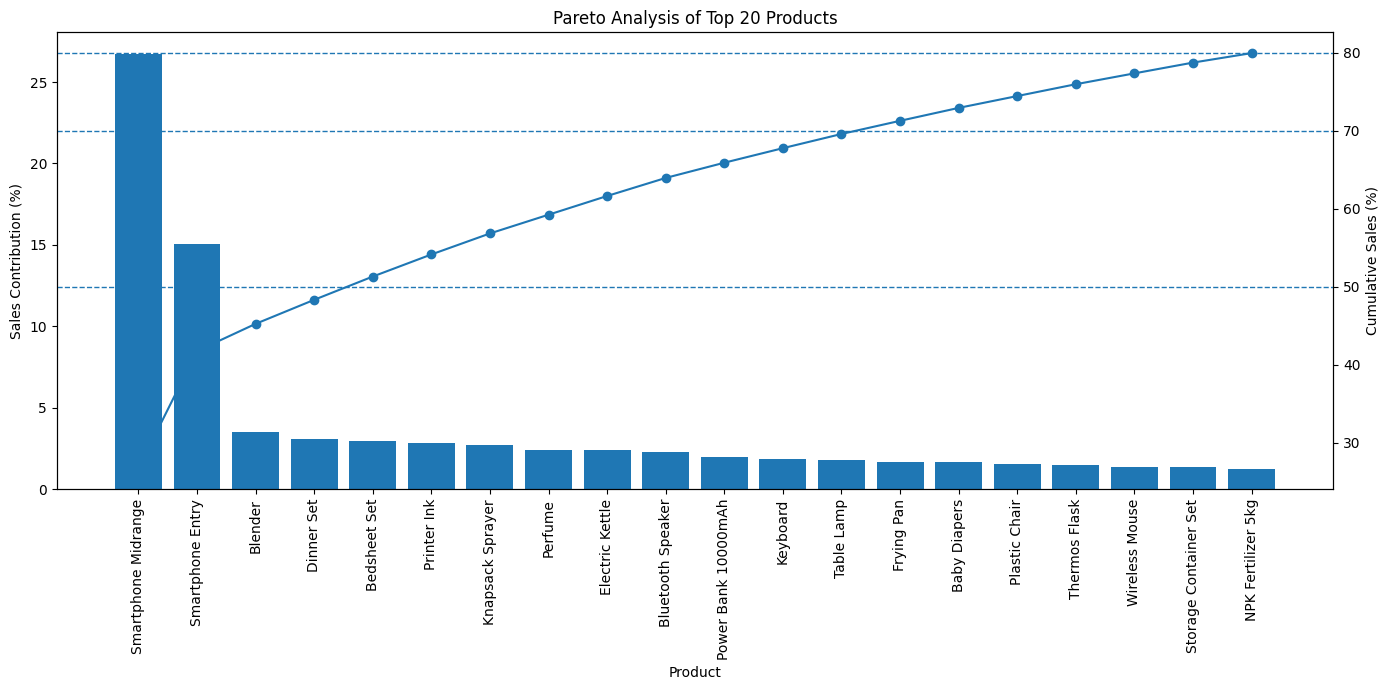

In [139]:
top20 = q7_summary.head(20).copy()

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.bar(
    top20["ProductName"],
    top20["Sales_Contribution_%"]
)

ax1.set_xlabel("Product")
ax1.set_ylabel("Sales Contribution (%)")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    top20["ProductName"],
    top20["Cumulative_%"],
    marker="o"
)

ax2.set_ylabel("Cumulative Sales (%)")

ax2.axhline(
    50,
    linestyle="--",
    linewidth=1
)

ax2.axhline(
    70,
    linestyle="--",
    linewidth=1
)

ax2.axhline(
    80,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Pareto Analysis of Top 20 Products"
)

plt.tight_layout()
plt.show()

In [140]:
product_50 = q7_summary.iloc[products_50 - 1]

product_70 = q7_summary.iloc[products_70 - 1]

product_80 = q7_summary.iloc[products_80 - 1]

print("50% point:")
print(
    product_50["ProductName"],
    "-",
    round(product_50["Cumulative_%"], 2),
    "%"
)

print("\n70% point:")
print(
    product_70["ProductName"],
    "-",
    round(product_70["Cumulative_%"], 2),
    "%"
)

print("\n80% point:")
print(
    product_80["ProductName"],
    "-",
    round(product_80["Cumulative_%"], 2),
    "%"
)

50% point:
Bedsheet Set - 51.32 %

70% point:
Frying Pan - 71.3 %

80% point:
USB-C Charger - 81.13 %


In [141]:
final_q7 = q7_summary[
    [
        "Rank",
        "ProductName",
        "Category",
        "Total_Net_Sales",
        "Sales_Contribution_%",
        "Cumulative_%"
    ]
].copy()

final_q7["Total_Net_Sales"] = (
    final_q7["Total_Net_Sales"] / 1_000_000
).round(2)

final_q7["Sales_Contribution_%"] = (
    final_q7["Sales_Contribution_%"]
).round(2)

final_q7["Cumulative_%"] = (
    final_q7["Cumulative_%"]
).round(2)

final_q7.head(20)

,Rank,ProductName,Category,Total_Net_Sales,Sales_Contribution_%,Cumulative_%
0,1,Smartphone Midrange,Electronics,329.77,26.72,26.72
1,2,Smartphone Entry,Electronics,185.78,15.05,41.77
2,3,Blender,Home & Kitchen,43.10,3.49,45.26
3,4,Dinner Set,Home & Kitchen,38.04,3.08,48.34
4,5,Bedsheet Set,Home & Kitchen,36.83,2.98,51.32
5,6,Printer Ink,Office & Stationery,34.98,2.83,54.16
6,7,Knapsack Sprayer,Agriculture,33.25,2.69,56.85
7,8,Perfume,Personal Care,29.68,2.40,59.26
8,9,Electric Kettle,Home & Kitchen,29.63,2.40,61.66
9,10,Bluetooth Speaker,Electronics,28.58,2.32,63.97


  Question 8: Which product Categories Are Driving the Business?

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [143]:
path = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(
    path,
    sheet_name="SalesRaw"
)

product = pd.read_excel(
    path,
    sheet_name="DimProduct"
)

In [144]:
print("Sales columns:")
print(sales.columns.tolist())

print("\nProduct columns:")
print(product.columns.tolist())

Sales columns:
['TransactionID', 'TransactionDate', 'StoreID', 'EmployeeID', 'CustomerID', 'ProductID', 'Quantity', 'UnitPrice', 'DiscountPct', 'SalesChannel', 'PaymentMethod', 'GrossSales', 'DiscountAmount', 'NetSales']

Product columns:
['ProductID', 'ProductName', 'Category', 'StandardUnitPrice', 'UnitCost']


In [145]:
q8 = sales.merge(
    product[
        [
            "ProductID",
            "ProductName",
            "Category",
            "UnitCost"
        ]
    ],
    on="ProductID",
    how="left"
)

In [146]:
q8["TotalCost"] = (
    q8["Quantity"] *
    q8["UnitCost"]
)

In [147]:
q8["GrossProfit"] = (
    q8["NetSales"] -
    q8["TotalCost"]
)

In [148]:
print(
    q8["Category"].value_counts()
)

Category
Personal Care          4244
Home & Kitchen         4240
Office & Stationery    4213
Food & Beverage        4133
Electronics            4113
Agriculture            4092
Name: count, dtype: int64


In [149]:
q8_summary = (
    q8.groupby("Category")
    .agg(
        Total_Net_Sales=("NetSales", "sum"),
        Quantity_Sold=("Quantity", "sum"),
        Gross_Profit=("GrossProfit", "sum"),
        Product_Count=("ProductID", "nunique")
    )
    .reset_index()
)

In [150]:
q8_summary["Sales_Contribution_%"] = (
    q8_summary["Total_Net_Sales"] /
    q8_summary["Total_Net_Sales"].sum()
) * 100

In [151]:
q8_summary["Profit_Margin_%"] = (
    q8_summary["Gross_Profit"] /
    q8_summary["Total_Net_Sales"]
) * 100

In [152]:
q8_summary = q8_summary.sort_values(
    "Total_Net_Sales",
    ascending=False
).reset_index(drop=True)

In [153]:
q8_display = q8_summary.copy()

q8_display["Total_Net_Sales"] = (
    q8_display["Total_Net_Sales"] /
    1_000_000
).round(2)

q8_display["Gross_Profit"] = (
    q8_display["Gross_Profit"] /
    1_000_000
).round(2)

q8_display["Sales_Contribution_%"] = (
    q8_display["Sales_Contribution_%"]
).round(2)

q8_display["Profit_Margin_%"] = (
    q8_display["Profit_Margin_%"]
).round(2)

q8_display

,Category,Total_Net_Sales,Quantity_Sold,Gross_Profit,Product_Count,Sales_Contribution_%,Profit_Margin_%
0,Electronics,648.83,10762,138.82,10,52.56,21.40
1,Home & Kitchen,251.55,11075,85.04,10,20.38,33.81
2,Agriculture,112.98,10401,35.52,10,9.15,31.44
3,Personal Care,99.74,11047,32.58,10,8.08,32.66
4,Office & Stationery,91.30,10858,29.79,10,7.40,32.63
5,Food & Beverage,29.97,10763,7.73,10,2.43,25.81


In [154]:
highest_sales_category = q8_summary.loc[
    q8_summary["Total_Net_Sales"].idxmax()
]

print("Highest sales category:")
print(highest_sales_category["Category"])

print(
    "Net Sales:",
    round(
        highest_sales_category["Total_Net_Sales"] /
        1_000_000,
        2
    ),
    "million RWF"
)

Highest sales category:
Electronics
Net Sales: 648.83 million RWF


In [155]:
highest_profit_category = q8_summary.loc[
    q8_summary["Gross_Profit"].idxmax()
]

print("Highest gross profit category:")
print(highest_profit_category["Category"])

print(
    "Gross Profit:",
    round(
        highest_profit_category["Gross_Profit"] /
        1_000_000,
        2
    ),
    "million RWF"
)

Highest gross profit category:
Electronics
Gross Profit: 138.82 million RWF


In [156]:
highest_margin_category = q8_summary.loc[
    q8_summary["Profit_Margin_%"].idxmax()
]

print("Highest profit margin category:")
print(highest_margin_category["Category"])

print(
    "Profit Margin:",
    round(
        highest_margin_category["Profit_Margin_%"],
        2
    ),
    "%"
)

Highest profit margin category:
Home & Kitchen
Profit Margin: 33.81 %


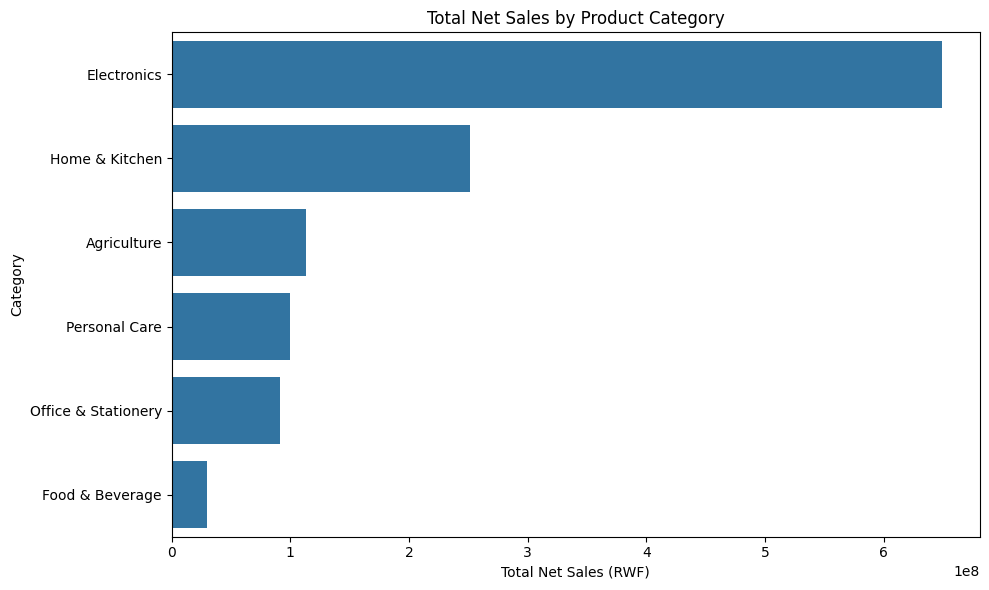

In [157]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=q8_summary,
    x="Total_Net_Sales",
    y="Category"
)

plt.xlabel("Total Net Sales (RWF)")
plt.ylabel("Category")
plt.title("Total Net Sales by Product Category")

plt.tight_layout()
plt.show()

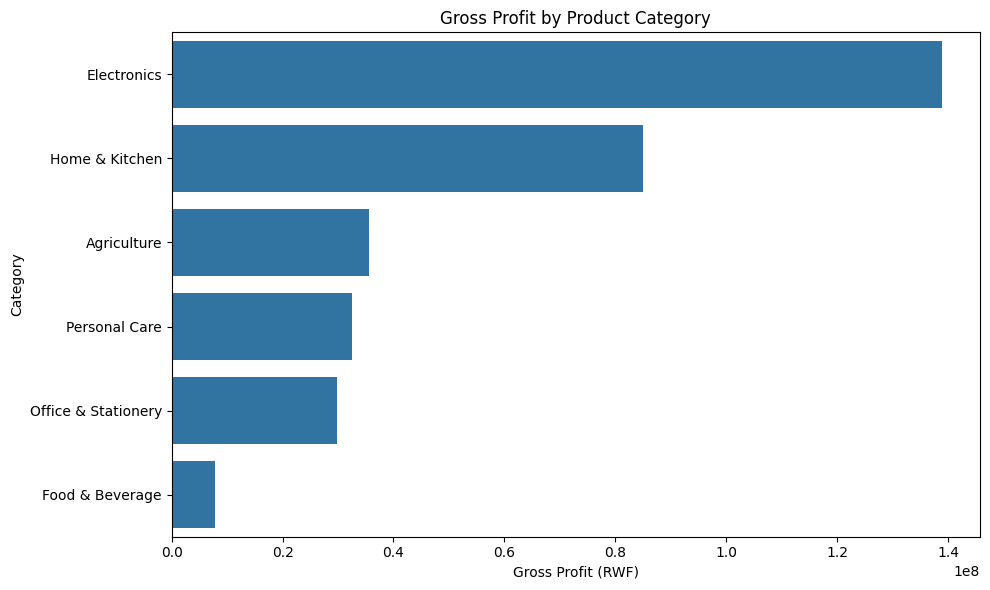

In [158]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=q8_summary,
    x="Gross_Profit",
    y="Category"
)

plt.xlabel("Gross Profit (RWF)")
plt.ylabel("Category")
plt.title("Gross Profit by Product Category")

plt.tight_layout()
plt.show()

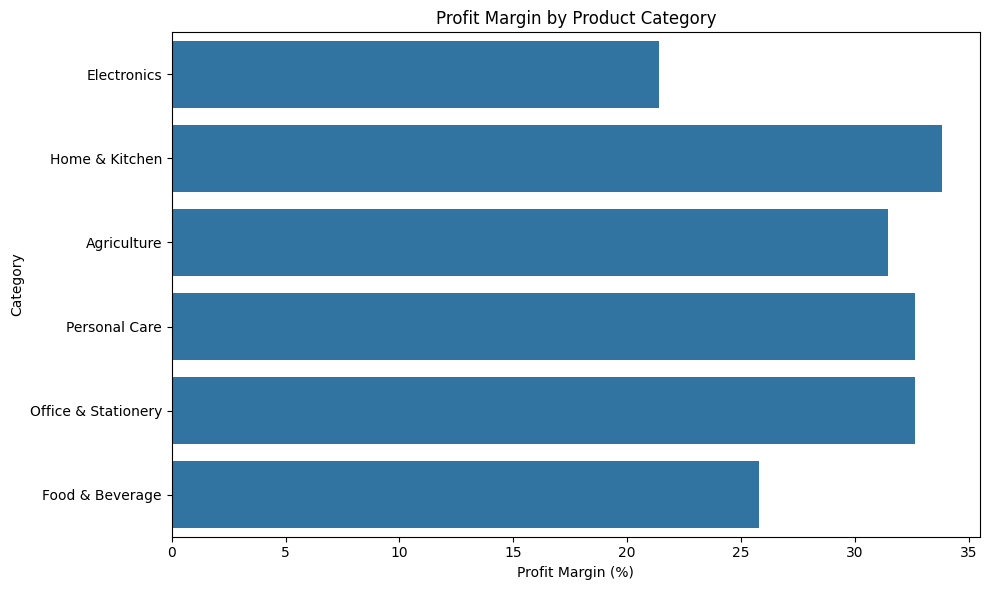

In [159]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=q8_summary,
    x="Profit_Margin_%",
    y="Category"
)

plt.xlabel("Profit Margin (%)")
plt.ylabel("Category")
plt.title("Profit Margin by Product Category")

plt.tight_layout()
plt.show()

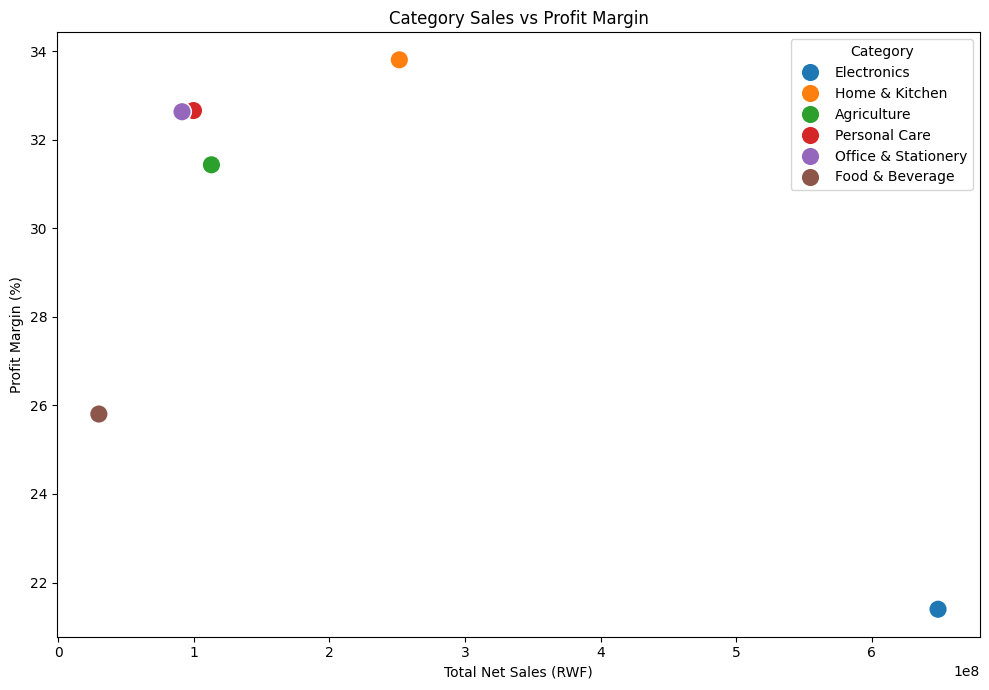

In [160]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=q8_summary,
    x="Total_Net_Sales",
    y="Profit_Margin_%",
    hue="Category",
    s=180
)

plt.xlabel("Total Net Sales (RWF)")
plt.ylabel("Profit Margin (%)")
plt.title("Category Sales vs Profit Margin")

plt.tight_layout()
plt.show()

In [161]:
final_q8 = q8_summary[
    [
        "Category",
        "Product_Count",
        "Total_Net_Sales",
        "Sales_Contribution_%",
        "Quantity_Sold",
        "Gross_Profit",
        "Profit_Margin_%"
    ]
].copy()

final_q8["Total_Net_Sales"] = (
    final_q8["Total_Net_Sales"] /
    1_000_000
).round(2)

final_q8["Gross_Profit"] = (
    final_q8["Gross_Profit"] /
    1_000_000
).round(2)

final_q8["Sales_Contribution_%"] = (
    final_q8["Sales_Contribution_%"]
).round(2)

final_q8["Profit_Margin_%"] = (
    final_q8["Profit_Margin_%"]
).round(2)

final_q8

,Category,Product_Count,Total_Net_Sales,Sales_Contribution_%,Quantity_Sold,Gross_Profit,Profit_Margin_%
0,Electronics,10,648.83,52.56,10762,138.82,21.40
1,Home & Kitchen,10,251.55,20.38,11075,85.04,33.81
2,Agriculture,10,112.98,9.15,10401,35.52,31.44
3,Personal Care,10,99.74,8.08,11047,32.58,32.66
4,Office & Stationery,10,91.30,7.40,10858,29.79,32.63
5,Food & Beverage,10,29.97,2.43,10763,7.73,25.81


Question 9: Can the Company Meet Its Sales Targets

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(path, sheet_name="SalesRaw")
targets = pd.read_excel(path, sheet_name="Targets")
store = pd.read_excel(path, sheet_name="DimStore")

print("Sales:", sales.shape)
print("Targets:", targets.shape)
print("Stores:", store.shape)

Sales: (25035, 14)
Targets: (96, 3)
Stores: (8, 5)


In [163]:
targets.head()

,Month,StoreID,SalesTarget
0,2025-01-01,1,17464775
1,2025-02-01,1,17674352
2,2025-03-01,1,17883929
3,2025-04-01,1,18093507
4,2025-05-01,1,18303084


In [164]:
sales["TransactionDate"] = pd.to_datetime(
    sales["TransactionDate"],
    errors="coerce"
)

sales["Month"] = sales["TransactionDate"].dt.to_period("M").astype(str)

sales[["TransactionDate", "Month", "NetSales"]].head()

,TransactionDate,Month,NetSales
0,2025-06-29,2025-06,4788.0
1,2025-12-31,2025-12,143662.8
2,2025-08-30,2025-08,8044.6
3,2025-06-09,2025-06,5457.0
4,2025-01-10,2025-01,2263.8


In [165]:
actual = (
    sales.groupby(["Month", "StoreID"])
    .agg(
        Actual_Sales=("NetSales", "sum"),
        Transactions=("TransactionID", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

actual.head()

,Month,StoreID,Actual_Sales,Transactions,Quantity
0,2025-01,1,23563586.51,429,1106
1,2025-01,2,13072065.77,343,873
2,2025-01,3,14430248.64,296,775
3,2025-01,4,11546387.91,259,701
4,2025-01,5,8305590.91,200,540


In [166]:
targets["Month"] = pd.to_datetime(
    targets["Month"],
    errors="coerce"
).dt.to_period("M").astype(str)

targets.head()

,Month,StoreID,SalesTarget
0,2025-01,1,17464775
1,2025-02,1,17674352
2,2025-03,1,17883929
3,2025-04,1,18093507
4,2025-05,1,18303084


In [167]:
q9 = actual.merge(
    targets[["Month", "StoreID", "SalesTarget"]],
    on=["Month", "StoreID"],
    how="left"
)

q9 = q9.merge(
    store[["StoreID", "StoreName"]],
    on="StoreID",
    how="left"
)

q9.head()

,Month,StoreID,Actual_Sales,Transactions,Quantity,SalesTarget,StoreName
0,2025-01,1,23563586.51,429,1106,17464775,Kigali City Centre
1,2025-01,2,13072065.77,343,873,18074483,Kimironko
2,2025-01,3,14430248.64,296,775,23763965,Kicukiro Mall
3,2025-01,4,11546387.91,259,701,22645508,Musanze Central
4,2025-01,5,8305590.91,200,540,19988105,Rubavu Centre


In [168]:
q9["Variance"] = (
    q9["Actual_Sales"] - q9["SalesTarget"]
)

In [169]:
q9["Achievement_%"] = (
    q9["Actual_Sales"] /
    q9["SalesTarget"]
) * 100

In [170]:
q9_display = q9.copy()

q9_display["Actual_Sales"] = (
    q9_display["Actual_Sales"] / 1_000_000
).round(2)

q9_display["SalesTarget"] = (
    q9_display["SalesTarget"] / 1_000_000
).round(2)

q9_display["Variance"] = (
    q9_display["Variance"] / 1_000_000
).round(2)

q9_display["Achievement_%"] = (
    q9_display["Achievement_%"]
).round(2)

q9_display[
    [
        "Month",
        "StoreName",
        "Actual_Sales",
        "SalesTarget",
        "Variance",
        "Achievement_%"
    ]
].head(20)

,Month,StoreName,Actual_Sales,SalesTarget,Variance,Achievement_%
0,2025-01,Kigali City Centre,23.56,17.46,6.10,134.92
1,2025-01,Kimironko,13.07,18.07,-5.00,72.32
2,2025-01,Kicukiro Mall,14.43,23.76,-9.33,60.72
3,2025-01,Musanze Central,11.55,22.65,-11.10,50.99
4,2025-01,Rubavu Centre,8.31,19.99,-11.68,41.55
5,2025-01,Huye Market,9.79,13.16,-3.37,74.41
6,2025-01,Nyagatare Plaza,15.84,20.90,-5.06,75.80
7,2025-01,Muhanga Hub,7.17,23.00,-15.83,31.19
8,2025-02,Kigali City Centre,14.67,17.67,-3.01,82.98
9,2025-02,Kimironko,15.25,18.29,-3.04,83.35


In [171]:
above_target = q9[q9["Variance"] > 0]

print("Store-months above target:",
      len(above_target))

Store-months above target: 9


In [172]:
store_target_summary = (
    q9.groupby(["StoreID", "StoreName"])
    .agg(
        Actual_Sales=("Actual_Sales", "sum"),
        Sales_Target=("SalesTarget", "sum")
    )
    .reset_index()
)

store_target_summary["Variance"] = (
    store_target_summary["Actual_Sales"] -
    store_target_summary["Sales_Target"]
)

store_target_summary["Achievement_%"] = (
    store_target_summary["Actual_Sales"] /
    store_target_summary["Sales_Target"]
) * 100

store_target_summary.sort_values(
    "Achievement_%",
    ascending=False
)

,StoreID,StoreName,Actual_Sales,Sales_Target,Variance,Achievement_%
0,1,Kigali City Centre,2.444683e+08,223409400,2.105893e+07,109.426161
1,2,Kimironko,1.850774e+08,231208792,-4.613142e+07,80.047724
5,6,Huye Market,1.202503e+08,168349961,-4.809962e+07,71.428790
2,3,Kicukiro Mall,1.591844e+08,303988639,-1.448042e+08,52.365257
4,5,Rubavu Centre,1.296607e+08,255687843,-1.260271e+08,50.710565
6,7,Nyagatare Plaza,1.325171e+08,267339124,-1.348220e+08,49.568916
3,4,Musanze Central,1.389773e+08,289681342,-1.507040e+08,47.975936
7,8,Muhanga Hub,1.242324e+08,294252929,-1.700206e+08,42.219582


In [173]:
q9.loc[
    q9["Variance"].idxmax(),
    [
        "Month",
        "StoreName",
        "Actual_Sales",
        "SalesTarget",
        "Variance",
        "Achievement_%"
    ]
]

,0
Month,2025-01
StoreName,Kigali City Centre
Actual_Sales,23563586.51
SalesTarget,17464775
Variance,6098811.51
Achievement_%,134.920642


In [174]:
q9.loc[
    q9["Variance"].idxmin(),
    [
        "Month",
        "StoreName",
        "Actual_Sales",
        "SalesTarget",
        "Variance",
        "Achievement_%"
    ]
]

,90
Month,2025-12
StoreName,Kicukiro Mall
Actual_Sales,9714502.42
SalesTarget,26900808
Variance,-17186305.58
Achievement_%,36.112307


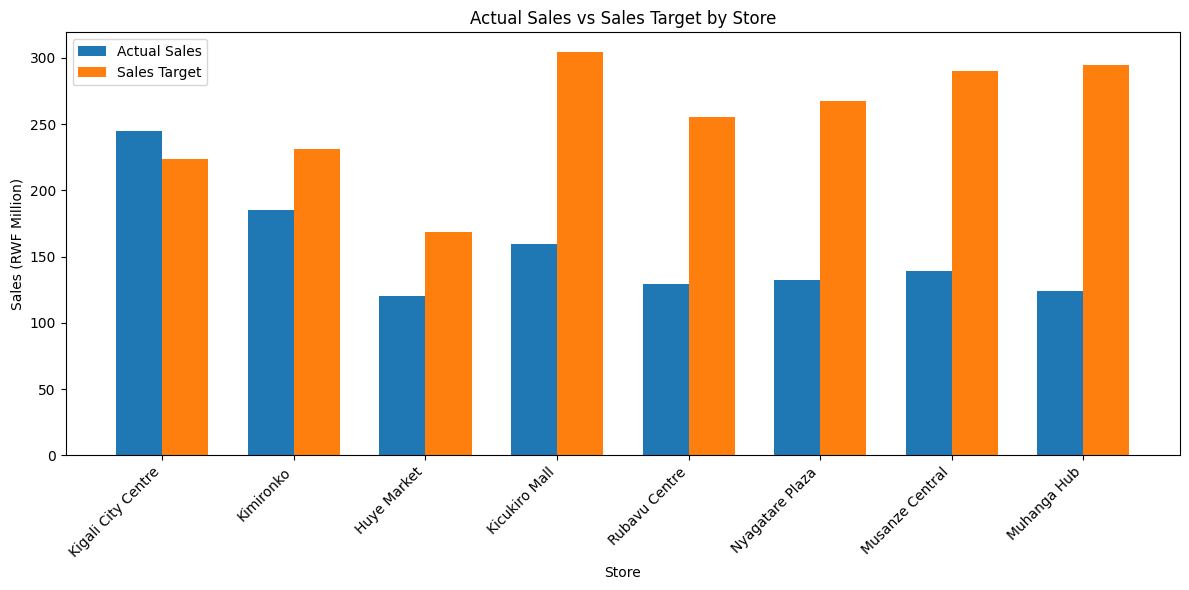

In [175]:
plot_data = store_target_summary.sort_values(
    "Achievement_%",
    ascending=False
)

x = np.arange(len(plot_data))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    plot_data["Actual_Sales"] / 1_000_000,
    width,
    label="Actual Sales"
)

plt.bar(
    x + width/2,
    plot_data["Sales_Target"] / 1_000_000,
    width,
    label="Sales Target"
)

plt.xticks(
    x,
    plot_data["StoreName"],
    rotation=45,
    ha="right"
)

plt.ylabel("Sales (RWF Million)")
plt.xlabel("Store")
plt.title("Actual Sales vs Sales Target by Store")
plt.legend()
plt.tight_layout()
plt.show()

In [176]:
above_target_display = q9[
    q9["Variance"] > 0
].copy()

above_target_display["Actual_Sales"] /= 1_000_000
above_target_display["SalesTarget"] /= 1_000_000
above_target_display["Variance"] /= 1_000_000

above_target_display[
    [
        "Month",
        "StoreName",
        "Actual_Sales",
        "SalesTarget",
        "Variance",
        "Achievement_%"
    ]
].sort_values(
    "Achievement_%",
    ascending=False
)

,Month,StoreName,Actual_Sales,SalesTarget,Variance,Achievement_%
0,2025-01,Kigali City Centre,23.563587,17.464775,6.098812,134.920642
88,2025-12,Kigali City Centre,25.191541,19.770125,5.421416,127.422267
64,2025-09,Kigali City Centre,24.156154,19.141393,5.014761,126.198515
40,2025-06,Kigali City Centre,22.893772,18.512661,4.381111,123.665484
48,2025-07,Kigali City Centre,22.945314,18.722239,4.223075,122.556463
80,2025-11,Kigali City Centre,23.476912,19.560548,3.916364,120.021749
56,2025-08,Kigali City Centre,21.639217,18.931816,2.707401,114.300797
16,2025-03,Kigali City Centre,18.906529,17.883929,1.022600,105.717985
17,2025-03,Kimironko,18.715577,18.508271,0.207306,101.120070


Question 10:Employee Performance and Management Decision

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "BI_Retail_Case_Study.xlsx"

sales = pd.read_excel(path, sheet_name="SalesRaw")
employee = pd.read_excel(path, sheet_name="DimEmployee")
store = pd.read_excel(path, sheet_name="DimStore")

print("Sales:", sales.shape)
print("Employees:", employee.shape)
print("Stores:", store.shape)

Sales: (25035, 14)
Employees: (40, 4)
Stores: (8, 5)


In [178]:
employee.head()

,EmployeeID,EmployeeName,Role,StoreID
0,2001,Employee 01,Cashier,2
1,2002,Employee 02,Sales Associate,4
2,2003,Employee 03,Sales Associate,1
3,2004,Employee 04,Sales Associate,8
4,2005,Employee 05,Sales Associate,2


In [179]:
q10 = sales.merge(
    employee[
        ["EmployeeID", "EmployeeName", "Role", "StoreID"]
    ],
    on="EmployeeID",
    how="left"
)

q10.head()

,TransactionID,TransactionDate,StoreID_x,EmployeeID,CustomerID,ProductID,Quantity,UnitPrice,DiscountPct,SalesChannel,PaymentMethod,GrossSales,DiscountAmount,NetSales,EmployeeName,Role,StoreID_y
0,TX100000,2025-06-29,3,2016,10538,10,2,2660.0,0.10,Store,Mobile Money,5320,532.0,4788.0,Employee 16,Sales Associate,3
1,TX100001,2025-12-31,6,2028,10107,26,6,25204.0,0.05,Store,Mobile Money,151224,7561.2,143662.8,Employee 28,Sales Associate,6
2,TX100002,2025-08-30,2,2036,13854,51,1,8468.0,0.05,Online,Bank Transfer,8468,423.4,8044.6,Employee 36,Sales Associate,2
3,TX100003,2025-06-09,5,2033,11230,3,3,1819.0,0.00,Store,Bank Transfer,5457,0.0,5457.0,Employee 33,Sales Associate,5
4,TX100004,2025-01-10,3,2019,10395,42,1,2310.0,0.02,Store,Card,2310,46.2,2263.8,Employee 19,Sales Associate,3


In [180]:
product = pd.read_excel(
    path,
    sheet_name="DimProduct"
)

q10 = q10.merge(
    product[
        ["ProductID", "UnitCost"]
    ],
    on="ProductID",
    how="left"
)

q10["TotalCost"] = (
    q10["Quantity"] * q10["UnitCost"]
)

q10["GrossProfit"] = (
    q10["NetSales"] - q10["TotalCost"]
)

In [181]:
employee_summary = (
    q10.groupby(
        [
            "EmployeeID",
            "EmployeeName",
            "Role"
        ]
    )
    .agg(
        Transactions=("TransactionID", "nunique"),
        Total_Sales=("NetSales", "sum"),
        Quantity_Sold=("Quantity", "sum"),
        Gross_Profit=("GrossProfit", "sum")
    )
    .reset_index()
)

In [182]:
employee_summary["Average_Transaction_Value"] = (
    employee_summary["Total_Sales"] /
    employee_summary["Transactions"]
)

In [183]:
employee_summary["Profit_Margin_%"] = (
    employee_summary["Gross_Profit"] /
    employee_summary["Total_Sales"]
) * 100

In [184]:
employee_display = employee_summary.copy()

employee_display["Total_Sales"] = (
    employee_display["Total_Sales"] / 1_000_000
).round(2)

employee_display["Gross_Profit"] = (
    employee_display["Gross_Profit"] / 1_000_000
).round(2)

employee_display["Average_Transaction_Value"] = (
    employee_display["Average_Transaction_Value"]
).round(2)

employee_display["Profit_Margin_%"] = (
    employee_display["Profit_Margin_%"]
).round(2)

employee_display.sort_values(
    "Total_Sales",
    ascending=False
)

,EmployeeID,EmployeeName,Role,Transactions,Total_Sales,Quantity_Sold,Gross_Profit,Average_Transaction_Value,Profit_Margin_%
3,2004,Employee 04,Sales Associate,1278,64.96,3323,17.75,50825.90,27.33
25,2026,Employee 26,Store Supervisor,1273,59.28,3316,15.70,46564.70,26.49
27,2028,Employee 28,Sales Associate,863,43.55,2288,11.44,50467.34,26.28
21,2022,Employee 22,Sales Associate,729,42.84,1954,11.73,58770.25,27.37
7,2008,Employee 08,Sales Associate,769,40.19,2030,10.94,52259.14,27.22
24,2025,Employee 25,Sales Associate,848,38.83,2215,10.34,45785.08,26.64
31,2032,Employee 32,Sales Associate,628,38.04,1582,8.78,60577.33,23.07
5,2006,Employee 06,Sales Associate,832,37.87,2165,10.02,45518.36,26.45
13,2014,Employee 14,Sales Associate,711,36.46,1890,9.72,51282.33,26.65
2,2003,Employee 03,Sales Associate,662,35.21,1746,9.07,53187.25,25.75


In [185]:
highest_sales = employee_summary.loc[
    employee_summary["Total_Sales"].idxmax()
]

highest_sales

,3
EmployeeID,2004
EmployeeName,Employee 04
Role,Sales Associate
Transactions,1278
Total_Sales,64955495.93
Quantity_Sold,3323
Gross_Profit,17754945.93
Average_Transaction_Value,50825.896659
Profit_Margin_%,27.334016


In [186]:
highest_atv = employee_summary.loc[
    employee_summary[
        "Average_Transaction_Value"
    ].idxmax()
]

highest_atv

,29
EmployeeID,2030
EmployeeName,Employee 30
Role,Sales Associate
Transactions,526
Total_Sales,33965534.87
Quantity_Sold,1429
Gross_Profit,8279734.87
Average_Transaction_Value,64573.260209
Profit_Margin_%,24.376872


In [187]:
highest_profit = employee_summary.loc[
    employee_summary[
        "Gross_Profit"
    ].idxmax()
]

highest_profit

,3
EmployeeID,2004
EmployeeName,Employee 04
Role,Sales Associate
Transactions,1278
Total_Sales,64955495.93
Quantity_Sold,3323
Gross_Profit,17754945.93
Average_Transaction_Value,50825.896659
Profit_Margin_%,27.334016


In [188]:
role_summary = (
    employee_summary.groupby("Role")
    .agg(
        Employees=("EmployeeID", "nunique"),
        Total_Sales=("Total_Sales", "sum"),
        Total_Profit=("Gross_Profit", "sum"),
        Total_Transactions=("Transactions", "sum"),
        Total_Quantity=("Quantity_Sold", "sum"),
        Average_Margin=("Profit_Margin_%", "mean")
    )
    .reset_index()
)

role_summary

,Role,Employees,Total_Sales,Total_Profit,Total_Transactions,Total_Quantity,Average_Margin
0,Cashier,7,1.774744e+08,5.026724e+07,4012,10366,28.401304
1,Sales Associate,26,8.346449e+08,2.209260e+08,16415,42674,26.488748
2,Store Supervisor,7,2.222487e+08,5.829810e+07,4573,11866,26.186365


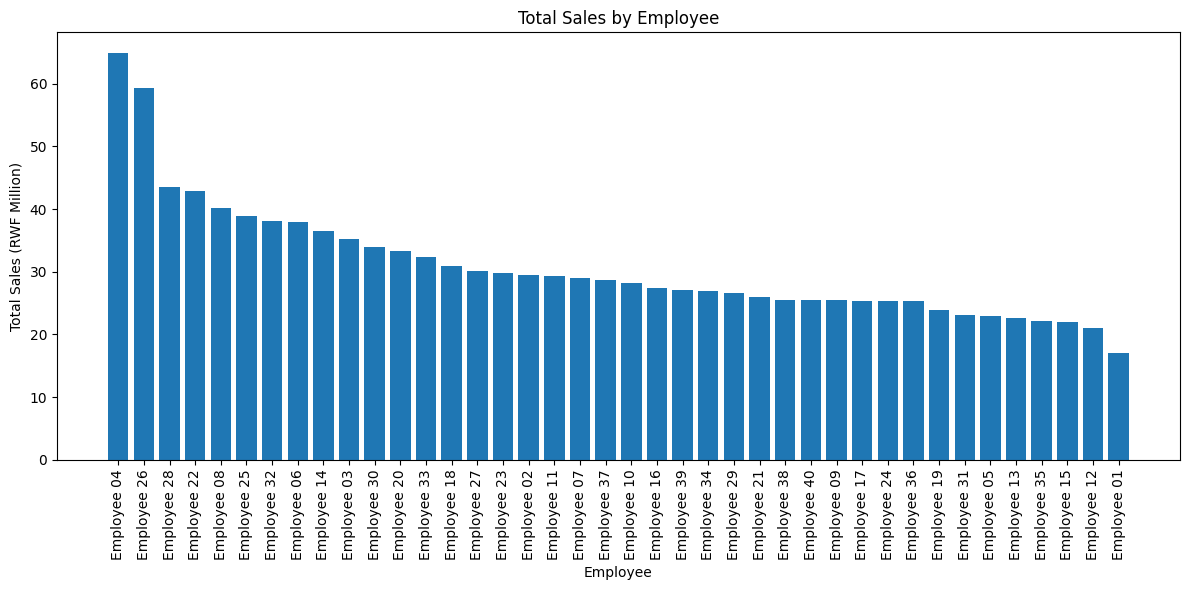

In [189]:
plt.figure(figsize=(12, 6))

plot_employee = employee_summary.sort_values(
    "Total_Sales",
    ascending=False
)

plt.bar(
    plot_employee["EmployeeName"],
    plot_employee["Total_Sales"] / 1_000_000
)

plt.xlabel("Employee")
plt.ylabel("Total Sales (RWF Million)")
plt.title("Total Sales by Employee")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

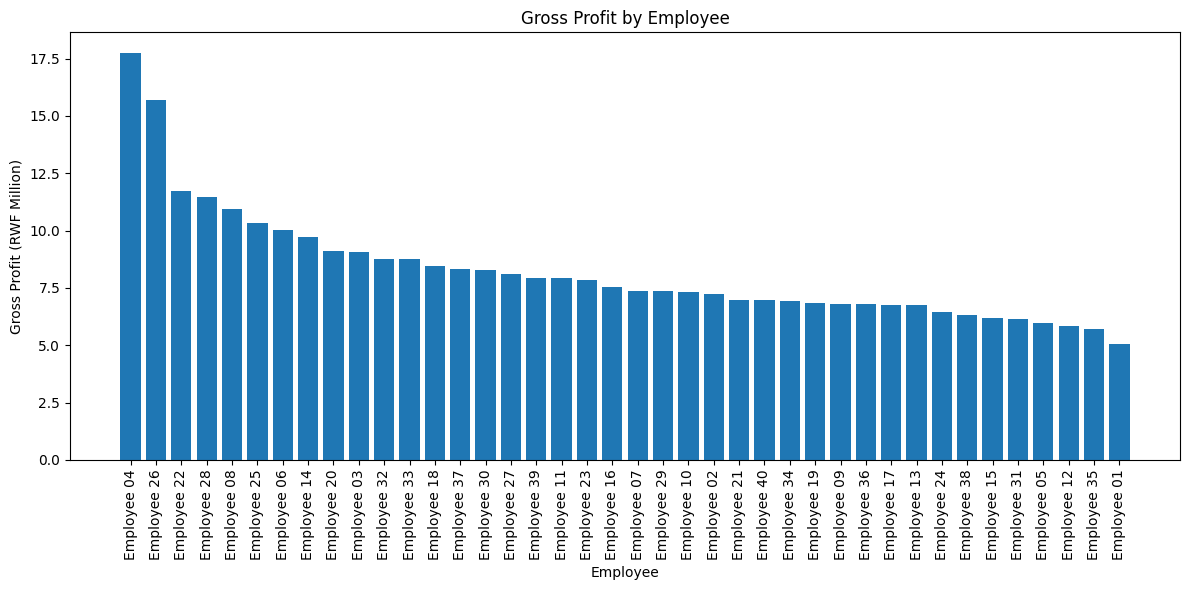

In [190]:
plt.figure(figsize=(12, 6))

plot_profit = employee_summary.sort_values(
    "Gross_Profit",
    ascending=False
)

plt.bar(
    plot_profit["EmployeeName"],
    plot_profit["Gross_Profit"] / 1_000_000
)

plt.xlabel("Employee")
plt.ylabel("Gross Profit (RWF Million)")
plt.title("Gross Profit by Employee")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

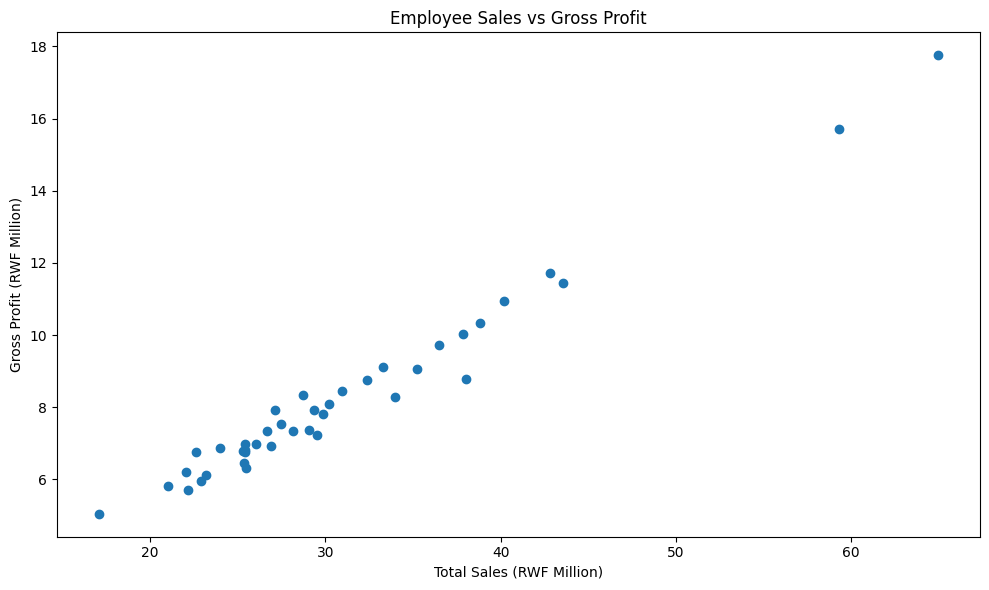

In [191]:
plt.figure(figsize=(10, 6))

plt.scatter(
    employee_summary["Total_Sales"] / 1_000_000,
    employee_summary["Gross_Profit"] / 1_000_000
)

plt.xlabel("Total Sales (RWF Million)")
plt.ylabel("Gross Profit (RWF Million)")
plt.title("Employee Sales vs Gross Profit")

plt.tight_layout()
plt.show()

In [192]:
print("Highest Total Sales:")
print(
    employee_summary.loc[
        employee_summary["Total_Sales"].idxmax(),
        ["EmployeeID", "EmployeeName", "Role", "Total_Sales"]
    ]
)

print("\nHighest Average Transaction Value:")
print(
    employee_summary.loc[
        employee_summary["Average_Transaction_Value"].idxmax(),
        [
            "EmployeeID",
            "EmployeeName",
            "Role",
            "Average_Transaction_Value"
        ]
    ]
)

print("\nHighest Gross Profit:")
print(
    employee_summary.loc[
        employee_summary["Gross_Profit"].idxmax(),
        [
            "EmployeeID",
            "EmployeeName",
            "Role",
            "Gross_Profit"
        ]
    ]
)

Highest Total Sales:
EmployeeID                 2004
EmployeeName        Employee 04
Role            Sales Associate
Total_Sales         64955495.93
Name: 3, dtype: object

Highest Average Transaction Value:
EmployeeID                              2030
EmployeeName                     Employee 30
Role                         Sales Associate
Average_Transaction_Value       64573.260209
Name: 29, dtype: object

Highest Gross Profit:
EmployeeID                 2004
EmployeeName        Employee 04
Role            Sales Associate
Gross_Profit        17754945.93
Name: 3, dtype: object
